# Hindi Fluency Experiment — Full Preprocessing & Analysis Pipeline (v3 — Corrected)

## Research Questions
1. Do Hindi speakers retrieve words in semantic clusters rather than randomly?
2. Do faster retrievals reflect tighter semantic neighbourhoods?
3. Does Hindi fluency predict lexical retrieval efficiency?
4. Does the order of domains within a session affect retrieval performance?
5. Do people pause longer before typing a word they place far from others in SpAM?
6. Do people who type more words in VFT also take less time to arrange them in SpAM?
7. Does the first word typed in VFT tend to be placed at the centre of the SpAM canvas?

---
**How to run:** Execute cells top-to-bottom. Upload `responses__1_.json` when prompted in Stage 1.

**v3 fixes applied:**
- RQ2 interpretation corrected: negative ρ means isolated words recalled FASTER (not "tighter = slower")
- RQ3 counter-theoretical findings now flagged with explicit caveat; median-split inconsistency noted
- RQ5 interpretation corrected: data shows close words take longer, not far words
- RQ7 primary test now the centroid distance (not canvas centre); canvas centre noted as ancillary
- Cross-join duplicate rows fixed: deduplicate df_cross on subject+domain+word after merge
- W=0.0 in RQ1 Wilcoxon now explicitly noted and discussed

---
# STAGE 0 — Install & Import Libraries

In [1]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from itertools import combinations
from scipy import stats
from scipy.stats import (pearsonr, spearmanr, ttest_ind, ttest_rel,
                          f_oneway, shapiro, mannwhitneyu, wilcoxon,
                          kruskal, levene)
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.gridspec as gridspec

warnings.filterwarnings('ignore')

# ── Global plot style ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
DOMAIN_COLORS = {
    'animals'   : '#4C72B0',
    'foods'     : '#DD8452',
    'body-parts': '#55A868',
    'colours'   : '#C44E52'
}

print('All libraries imported successfully.')

All libraries imported successfully.


---
# STAGE 1 — File Upload & Raw Data Loading

In [2]:
from google.colab import files
print('Please upload your responses__1_.json file:')
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f'\nFile uploaded: {filename}')

Please upload your responses__1_.json file:


Saving responses (1).json to responses (1).json

File uploaded: responses (1).json


In [3]:
with open(filename, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

participants = raw_data['fluency-spam']
print(f'Total participant sessions found: {len(participants)}')
print('Note: Experiment brief mentions 30 participants — 35 present; all included.')

Total participant sessions found: 35
Note: Experiment brief mentions 30 participants — 35 present; all included.


---
# STAGE 2 — Raw Extraction

Separate every participant's trial records into VFT trials, SpAM trials, and Demographics.
Practice domain (`furniture-practice`) is excluded throughout.

In [4]:
def safe_parse(value):
    if isinstance(value, str):
        try: return json.loads(value)
        except: return value
    return value

raw_vft, raw_spam, raw_demo = [], [], []

for sess_key, p_data in participants.items():
    subj_id = p_data['subject_id']

    for trial in p_data['data']:
        task   = trial.get('task', '')
        domain = trial.get('domain', '')
        if 'practice' in domain:
            continue

        if task == 'VFT' and 'tagged_responses' in trial:
            tagged  = safe_parse(trial['tagged_responses'])
            rt_list = safe_parse(trial['response_times'])
            trial_idx   = trial.get('trial_index', None)
            position_map = {8: 1, 12: 2, 16: 3}
            session_pos  = position_map.get(trial_idx, None)
            raw_vft.append({'subject_id': subj_id, 'domain': domain,
                            'session_pos': session_pos, 'trial_index': trial_idx,
                            'tagged': tagged, 'rt_list': rt_list,
                            'time_elapsed': trial.get('time_elapsed')})

        if task == 'SpAM' and 'droppedwords' in trial:
            dw = trial.get('droppedwords', [])
            if isinstance(dw, str): dw = safe_parse(dw)
            raw_spam.append({'subject_id': subj_id, 'domain': domain,
                             'rt_ms': trial.get('rt'), 'droppedwords': dw,
                             'viewport_width': trial.get('viewport_width'),
                             'viewport_height': trial.get('viewport_height')})

    demo = {'subject_id': subj_id}
    for trial in p_data['data']:
        tt   = trial.get('typeoftrial', '')
        resp = trial.get('response', {}) or {}
        if isinstance(resp, str):
            try: resp = json.loads(resp)
            except: pass
        if tt == 'insights':
            demo['Hi_Read']    = int(trial.get('Hi_Read')  or resp.get('Hi_Read',  0))
            demo['Hi_Write']   = int(trial.get('Hi_Write') or resp.get('Hi_Write', 0))
            demo['En_Read']    = int(trial.get('En_Read')  or resp.get('En_Read',  0))
            demo['En_Write']   = int(trial.get('En_Write') or resp.get('En_Write', 0))
            demo['strategies'] = resp.get('strategies', '')
        if tt == 'demographics':
            for k in ['first_language','language_count','languages_buffer',
                      'age','gender','education','state_ut','dominant_hand','alert_time']:
                if k in resp: demo[k] = resp[k]
            conf_keys = sorted([k for k in resp if k.startswith('confidence_')])
            if conf_keys: demo['confidence_scores'] = [int(resp[k]) for k in conf_keys]
            acq_keys  = sorted([k for k in resp if k.startswith('acquisition_')])
            if acq_keys:  demo['acquisition_codes']  = [int(resp[k]) for k in acq_keys]
    raw_demo.append(demo)

print(f'VFT trials extracted     : {len(raw_vft)}')
print(f'SpAM trials extracted    : {len(raw_spam)}')
print(f'Participant demo records : {len(raw_demo)}')

VFT trials extracted     : 105
SpAM trials extracted    : 105
Participant demo records : 35


---
# STAGE 3 — VFT Data Cleaning

**Steps:**
1. Remove duplicate words within each trial (keep first occurrence)
2. Re-number tags sequentially after deduplication
3. Compute word count and mean IRT per trial

In [5]:
vft_word_rows, vft_trial_rows, duplicates_removed = [], [], []

for trial in raw_vft:
    subj_id     = trial['subject_id']
    domain      = trial['domain']
    session_pos = trial['session_pos']
    tagged      = trial['tagged']
    rt_list     = trial['rt_list']

    seen_words, clean_words = set(), []
    for i, entry in enumerate(tagged):
        word_raw   = entry['response'].strip()
        word_lower = word_raw.lower()
        irt        = float(rt_list[i]) if i < len(rt_list) else None
        if word_lower in seen_words:
            duplicates_removed.append({'subject_id': subj_id, 'domain': domain,
                                       'word': word_raw, 'tag': entry['tag'],
                                       'reason': 'duplicate word in VFT'})
            continue
        seen_words.add(word_lower)
        clean_words.append({'word': word_raw, 'irt_ms': irt})

    for new_tag, w in enumerate(clean_words, start=1):
        w['tag'] = new_tag

    word_count = len(clean_words)
    irt_values = [w['irt_ms'] for w in clean_words if w['irt_ms'] is not None]
    mean_irt   = float(np.mean(irt_values)) if irt_values else None

    for w in clean_words:
        vft_word_rows.append({'subject_id': subj_id, 'domain': domain,
                              'session_pos': session_pos, 'word': w['word'],
                              'word_lower': w['word'].lower().strip(),
                              'tag': w['tag'], 'irt_ms': w['irt_ms'],
                              'word_count': word_count, 'mean_irt_trial': mean_irt})
    vft_trial_rows.append({'subject_id': subj_id, 'domain': domain,
                           'session_pos': session_pos,
                           'word_count': word_count, 'mean_irt_ms': mean_irt})

df_vft_words  = pd.DataFrame(vft_word_rows)
df_vft_trials = pd.DataFrame(vft_trial_rows)
df_dups_vft   = pd.DataFrame(duplicates_removed)

print(f'VFT word-level table    : {len(df_vft_words)} rows')
print(f'VFT trial-level table   : {len(df_vft_trials)} rows')
print(f'Duplicate words removed : {len(df_dups_vft)}')
if len(df_dups_vft) > 0:
    print()
    print(df_dups_vft.to_string(index=False))

VFT word-level table    : 1037 rows
VFT trial-level table   : 105 rows
Duplicate words removed : 7

 subject_id     domain   word  tag                reason
      95712    colours   नीला    6 duplicate word in VFT
      68981 body-parts    सिर    2 duplicate word in VFT
      61476    colours  peela    9 duplicate word in VFT
      61476    colours   hara   10 duplicate word in VFT
      62335    animals   चीता    8 duplicate word in VFT
      81788    colours orange    9 duplicate word in VFT
      34350    colours   pink    8 duplicate word in VFT


## VFT Preprocessing Visualisations

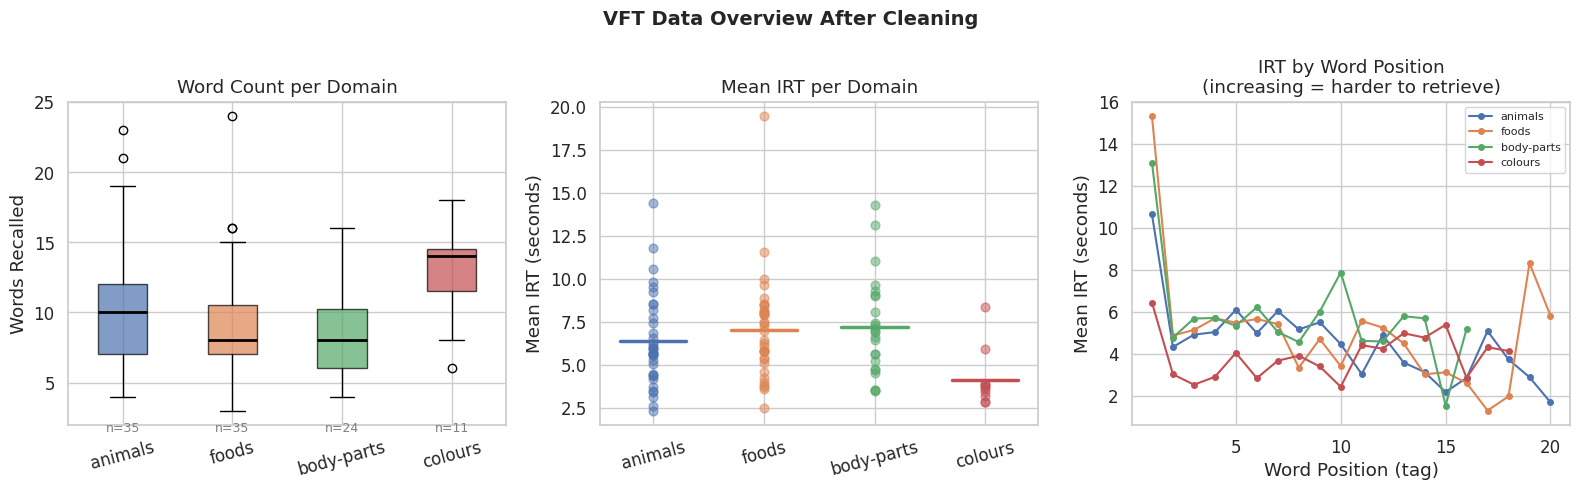

Figure saved: viz_vft_overview.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('VFT Data Overview After Cleaning', fontsize=14, fontweight='bold')

domain_order = ['animals','foods','body-parts','colours']
data_for_box = [df_vft_trials[df_vft_trials['domain']==d]['word_count'].values for d in domain_order]
bp = axes[0].boxplot(data_for_box, patch_artist=True, notch=False,
                     medianprops=dict(color='black', linewidth=2))
for patch, d in zip(bp['boxes'], domain_order):
    patch.set_facecolor(DOMAIN_COLORS[d]); patch.set_alpha(0.7)
axes[0].set_xticklabels(domain_order, rotation=15)
axes[0].set_ylabel('Words Recalled'); axes[0].set_title('Word Count per Domain')
for i, d in enumerate(domain_order, start=1):
    n = df_vft_trials[df_vft_trials['domain']==d].shape[0]
    axes[0].text(i, axes[0].get_ylim()[0]-0.5, f'n={n}', ha='center', fontsize=9, color='gray')

for i, d in enumerate(domain_order):
    vals = df_vft_trials[df_vft_trials['domain']==d]['mean_irt_ms'].dropna() / 1000
    axes[1].scatter([i+1]*len(vals), vals, color=DOMAIN_COLORS[d], alpha=0.5, s=40)
    axes[1].plot([i+0.7, i+1.3], [vals.mean(), vals.mean()], color=DOMAIN_COLORS[d], linewidth=2.5)
axes[1].set_xticks(range(1,5)); axes[1].set_xticklabels(domain_order, rotation=15)
axes[1].set_ylabel('Mean IRT (seconds)'); axes[1].set_title('Mean IRT per Domain')

for d in domain_order:
    d_data = df_vft_words[df_vft_words['domain']==d]
    pos_mean = (d_data.groupby('tag')['irt_ms'].mean() / 1000)
    pos_mean = pos_mean[pos_mean.index <= 20]
    axes[2].plot(pos_mean.index, pos_mean.values, marker='o', markersize=4,
                 color=DOMAIN_COLORS[d], label=d, linewidth=1.5)
axes[2].set_xlabel('Word Position (tag)'); axes[2].set_ylabel('Mean IRT (seconds)')
axes[2].set_title('IRT by Word Position\n(increasing = harder to retrieve)'); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('viz_vft_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: viz_vft_overview.png')

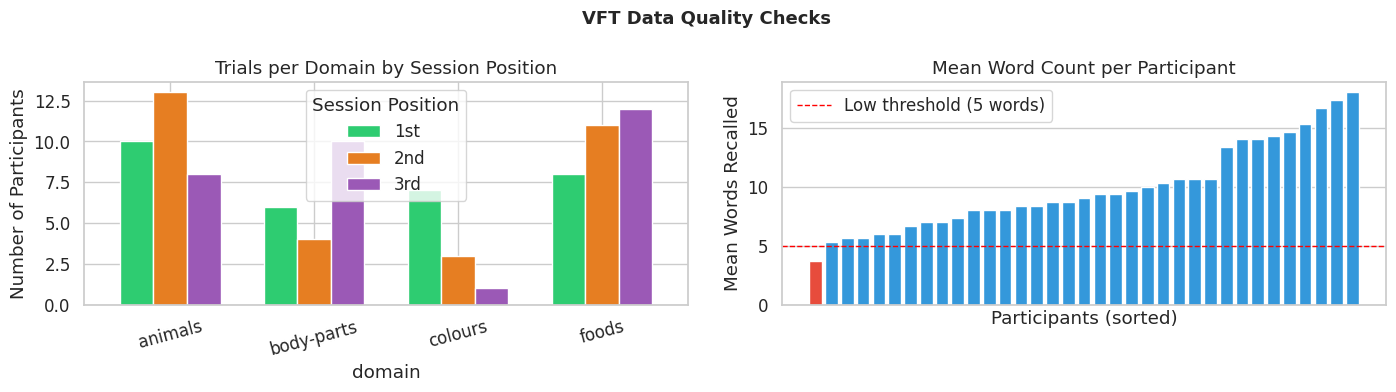

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('VFT Data Quality Checks', fontsize=13, fontweight='bold')

pos_counts = df_vft_trials.groupby(['domain','session_pos']).size().unstack(fill_value=0)
pos_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71','#e67e22','#9b59b6'],
                edgecolor='white', width=0.7)
axes[0].set_title('Trials per Domain by Session Position')
axes[0].set_ylabel('Number of Participants')
axes[0].set_xticklabels(pos_counts.index, rotation=15)
axes[0].legend(title='Session Position', labels=['1st','2nd','3rd'])

per_subj = df_vft_trials.groupby('subject_id')['word_count'].mean().sort_values()
colors_bar = ['#e74c3c' if v < 5 else '#3498db' for v in per_subj.values]
axes[1].bar(range(len(per_subj)), per_subj.values, color=colors_bar, edgecolor='white')
axes[1].axhline(5, color='red', linestyle='--', linewidth=1, label='Low threshold (5 words)')
axes[1].set_xlabel('Participants (sorted)'); axes[1].set_ylabel('Mean Words Recalled')
axes[1].set_title('Mean Word Count per Participant'); axes[1].set_xticks([]); axes[1].legend()

plt.tight_layout()
plt.savefig('viz_data_quality.png', dpi=150, bbox_inches='tight')
plt.show()

---
# STAGE 4 — SpAM Data Cleaning

**Steps:**
1. Keep only the **last placement** per word-id (all drag events logged; only final position matters)
2. Apply **Hindi→English word mapping** for subjects 68981 & 72898
3. **Clip** normalised coordinates to [0, 1]
4. Compute **pairwise Euclidean distances** and **mean neighbourhood distance** per word

In [8]:
HINDI_TO_ENGLISH = {
    'सिर':'head','कान':'ear','नाक':'nose','मुँह':'mouth','हाथ':'hand',
    'उंगली':'finger','दिल':'heart','बाल':'hair','आँख':'eye','होंठ':'lips',
    'गर्दन':'neck','जीभ':'tongue','कुत्ता':'dog','बिल्ली':'cat','शेर':'lion',
    'बाघ':'tiger','हाथी':'elephant','घोड़ा':'horse','बंदर':'monkey','बकरी':'goat',
    'भेड़':'lamb','खरगोश':'rabbit','भालू':'bear','गाय':'cow','बैल':'bull',
    'ऊँट':'camel','सूअर':'pig','चावल':'rice','रोटी':'bread','दूध':'milk',
    'केला':'banana','आम':'mango','अंडा':'egg','मछली':'fish','छाछ':'buttermilk',
    'खोया':'khoya','मक्खन':'butter','घी':'ghee','पनीर':'cheese',
    'प्रजातियाँ':'species',
}
HINDI_SUBJECTS = {68981, 72898}

spam_word_rows, spam_trial_rows, move_counts = [], [], []

for trial in raw_spam:
    subj_id = trial['subject_id']
    domain  = trial['domain']
    rt_ms   = trial['rt_ms']
    dw      = trial['droppedwords']

    id_counts = Counter(p['id'] for p in dw)
    move_counts.extend(list(id_counts.values()))

    # Keep last position per word-id
    final_positions = {}
    for placement in dw:
        final_positions[placement['id']] = placement

    cleaned = []
    for wid, p in final_positions.items():
        x = float(np.clip(p['x_norm'], 0.0, 1.0))
        y = float(np.clip(p['y_norm'], 0.0, 1.0))
        cleaned.append({'word_id': wid, 'word': p['word'].strip(),
                        'word_lower': p['word'].strip().lower(), 'x_norm': x, 'y_norm': y})

    n = len(cleaned)
    if n < 2:
        print(f'  WARNING: subject {subj_id} domain {domain} — fewer than 2 words placed, skipped.')
        continue

    coords = np.array([[p['x_norm'], p['y_norm']] for p in cleaned])
    mean_nb_dists = [float(np.mean([np.linalg.norm(coords[i]-coords[j])
                                    for j in range(n) if j!=i])) for i in range(n)]
    centroid_x = float(np.mean(coords[:,0]))
    centroid_y = float(np.mean(coords[:,1]))
    centroid_dists = [float(np.linalg.norm(coords[i]-np.array([centroid_x,centroid_y])))
                      for i in range(n)]

    for i, p in enumerate(cleaned):
        spam_word_rows.append({'subject_id': subj_id, 'domain': domain,
                               'word': p['word'], 'word_lower': p['word_lower'],
                               'x_norm': p['x_norm'], 'y_norm': p['y_norm'],
                               'mean_neighbour_dist': mean_nb_dists[i],
                               'centroid_dist': centroid_dists[i],
                               'centroid_x': centroid_x, 'centroid_y': centroid_y})
    spam_trial_rows.append({'subject_id': subj_id, 'domain': domain,
                            'spam_rt_ms': rt_ms, 'spam_words_placed': n,
                            'centroid_x': centroid_x, 'centroid_y': centroid_y})

df_spam_words  = pd.DataFrame(spam_word_rows)
df_spam_trials = pd.DataFrame(spam_trial_rows)

# Apply word normalisation for Hindi-script participants
def normalise_word(row):
    if row['subject_id'] in HINDI_SUBJECTS:
        mapped = HINDI_TO_ENGLISH.get(row['word'], None)
        if mapped: return mapped
    return row['word_lower']

df_vft_words['word_norm']  = df_vft_words.apply(normalise_word, axis=1)
df_spam_words['word_norm'] = df_spam_words['word_lower'].str.lower().str.strip()

print(f'SpAM word-level table  : {len(df_spam_words)} rows')
print(f'SpAM trial-level table : {len(df_spam_trials)} rows')
moves_arr = np.array(move_counts)
print(f'Word drag events total : {len(moves_arr)}')
print(f'  Mean moves per word  : {moves_arr.mean():.2f}')
print(f'  Words moved >1 time  : {(moves_arr > 1).sum()} ({100*(moves_arr>1).mean():.1f}%)')

SpAM word-level table  : 1040 rows
SpAM trial-level table : 105 rows
Word drag events total : 1040
  Mean moves per word  : 1.60
  Words moved >1 time  : 392 (37.7%)


## SpAM Preprocessing Visualisations

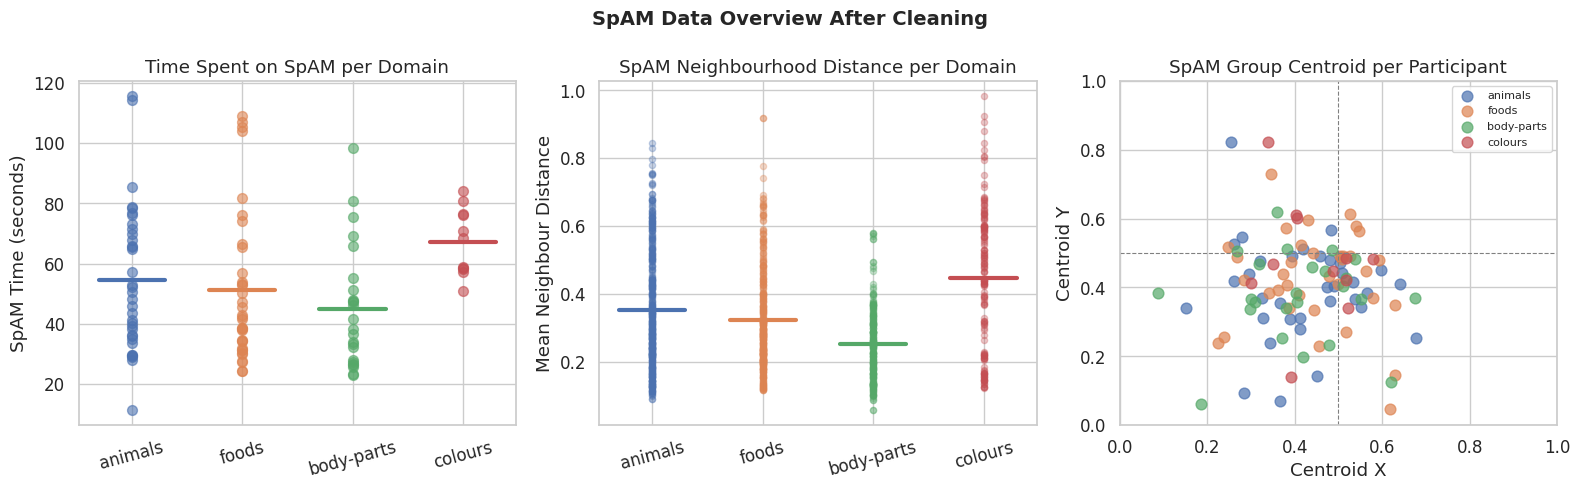

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('SpAM Data Overview After Cleaning', fontsize=14, fontweight='bold')

domain_order = ['animals','foods','body-parts','colours']
for i, d in enumerate(domain_order):
    vals = df_spam_trials[df_spam_trials['domain']==d]['spam_rt_ms'].dropna() / 1000
    axes[0].scatter([i+1]*len(vals), vals, color=DOMAIN_COLORS[d], alpha=0.6, s=50)
    if len(vals): axes[0].plot([i+0.7,i+1.3],[vals.mean(),vals.mean()], color=DOMAIN_COLORS[d], linewidth=3)
axes[0].set_xticks(range(1,5)); axes[0].set_xticklabels(domain_order, rotation=15)
axes[0].set_ylabel('SpAM Time (seconds)'); axes[0].set_title('Time Spent on SpAM per Domain')

for i, d in enumerate(domain_order):
    vals = df_spam_words[df_spam_words['domain']==d]['mean_neighbour_dist'].dropna()
    axes[1].scatter([i+1]*len(vals), vals, color=DOMAIN_COLORS[d], alpha=0.3, s=20)
    if len(vals): axes[1].plot([i+0.7,i+1.3],[vals.mean(),vals.mean()], color=DOMAIN_COLORS[d], linewidth=3)
axes[1].set_xticks(range(1,5)); axes[1].set_xticklabels(domain_order, rotation=15)
axes[1].set_ylabel('Mean Neighbour Distance'); axes[1].set_title('SpAM Neighbourhood Distance per Domain')

for d in domain_order:
    sub = df_spam_trials[df_spam_trials['domain']==d]
    axes[2].scatter(sub['centroid_x'], sub['centroid_y'], color=DOMAIN_COLORS[d], alpha=0.7, s=60, label=d)
axes[2].axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
axes[2].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_xlim(0,1); axes[2].set_ylim(0,1)
axes[2].set_xlabel('Centroid X'); axes[2].set_ylabel('Centroid Y')
axes[2].set_title('SpAM Group Centroid per Participant'); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('viz_spam_overview.png', dpi=150, bbox_inches='tight')
plt.show()

---
# STAGE 5 — Demographics Cleaning

In [10]:
demo_rows = []
for d in raw_demo:
    subj_id  = d['subject_id']
    lang_buf = d.get('languages_buffer', '')
    hindi_idx, hindi_acq, hindi_conf = None, None, None

    if lang_buf:
        lang_list = [l.strip() for l in lang_buf.split('||')]
        for i, lang in enumerate(lang_list):
            if 'hindi' in lang.lower() or lang.lower() == 'hini':
                hindi_idx = i; break
        acq_codes = d.get('acquisition_codes', [])
        if hindi_idx is not None and hindi_idx < len(acq_codes):
            hindi_acq = acq_codes[hindi_idx]
        conf_scores = d.get('confidence_scores', [])
        if hindi_idx is not None and hindi_idx < len(conf_scores):
            hindi_conf = conf_scores[hindi_idx]

    hi_read  = d.get('Hi_Read',  0)
    hi_write = d.get('Hi_Write', 0)
    hindi_fluency   = hi_read + hi_write
    acq_label_map   = {1: 'home/native', 2: 'school', 3: 'other'}
    hindi_acq_label = acq_label_map.get(hindi_acq, 'unknown')

    fl = str(d.get('first_language', 'unknown')).strip()
    fl_norm_map = {'hindi': 'Hindi', 'gujarti': 'Gujarati', 'gujarati': 'Gujarati',
                   'gUjarati': 'Gujarati', 'gujarati ': 'Gujarati'}
    fl_clean = fl_norm_map.get(fl.lower().strip(), fl)

    demo_rows.append({
        'subject_id': subj_id, 'first_language': fl_clean,
        'languages_buffer': lang_buf, 'language_count': d.get('language_count'),
        'Hi_Read': hi_read, 'Hi_Write': hi_write,
        'En_Read': d.get('En_Read',0), 'En_Write': d.get('En_Write',0),
        'hindi_fluency': hindi_fluency,
        'hindi_acq_code': hindi_acq, 'hindi_acq_label': hindi_acq_label,
        'hindi_confidence': hindi_conf,
        'age': d.get('age'), 'gender': d.get('gender'),
        'education_yrs': d.get('education'), 'state_ut': d.get('state_ut'),
        'dominant_hand': d.get('dominant_hand'), 'alert_time': d.get('alert_time'),
        'strategies': d.get('strategies','')
    })

df_demo = pd.DataFrame(demo_rows)
print(f'Demographics table: {len(df_demo)} participants')
print(f'\nHindi fluency composite range: {df_demo["hindi_fluency"].min()} – {df_demo["hindi_fluency"].max()}')
print('Hindi acquisition breakdown:')
print(df_demo['hindi_acq_label'].value_counts().to_string())
print('\nFirst language (normalised):')
print(df_demo['first_language'].value_counts().to_string())

Demographics table: 35 participants

Hindi fluency composite range: 4 – 10
Hindi acquisition breakdown:
hindi_acq_label
home/native    19
school         11
other           4
unknown         1

First language (normalised):
first_language
Hindi       20
Gujarati     7
English      5
Telugu       2
Punjabi      1


## Demographics Visualisations

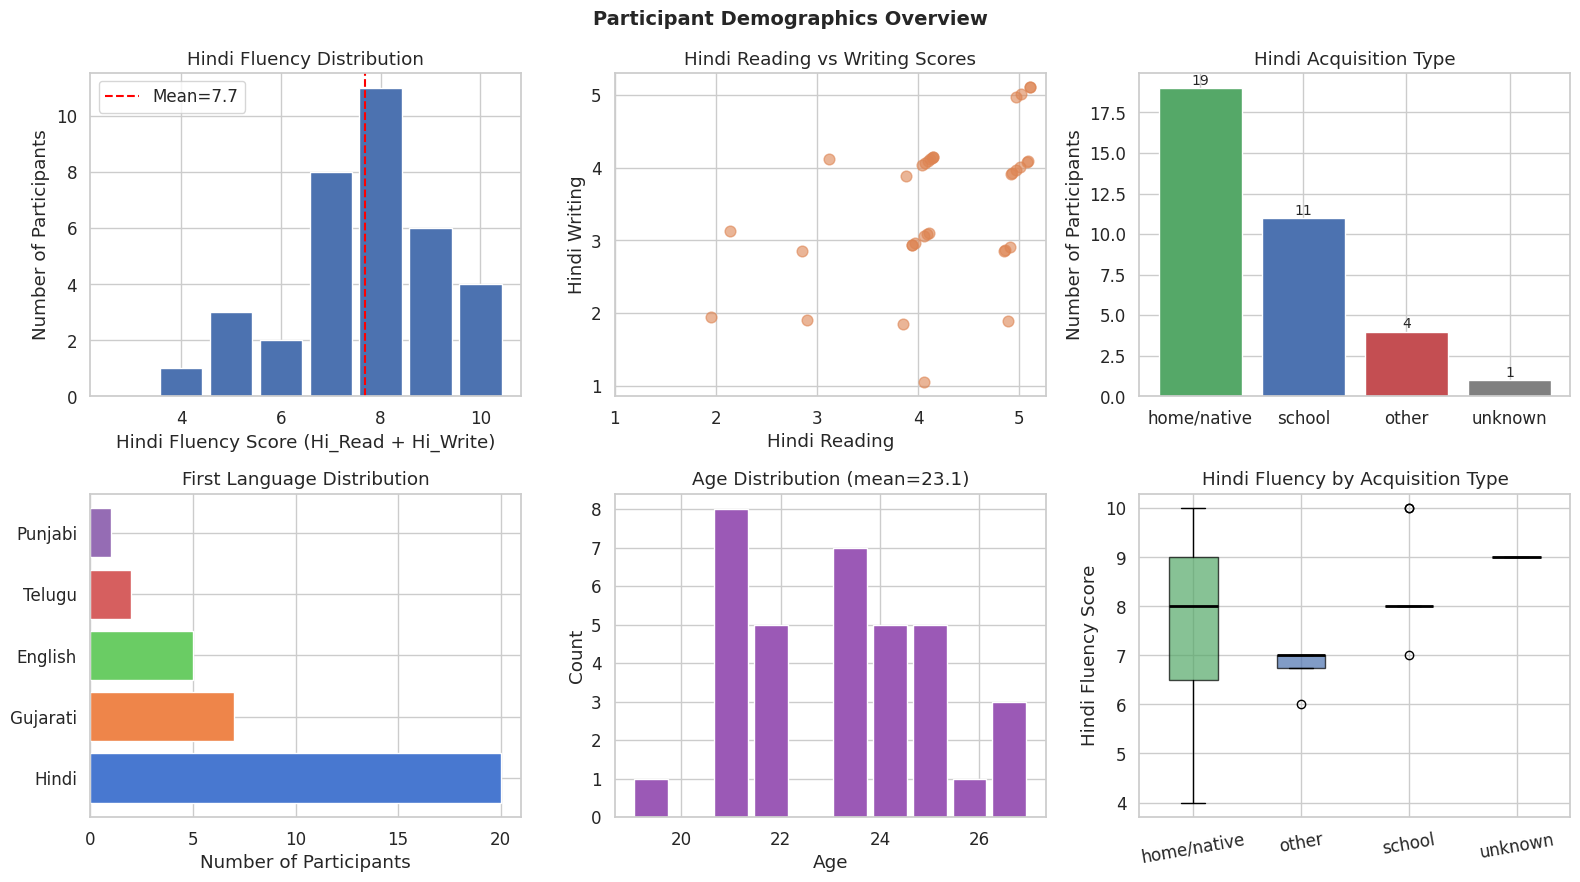

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Participant Demographics Overview', fontsize=14, fontweight='bold')

ax = axes[0,0]
ax.hist(df_demo['hindi_fluency'], bins=range(3,12), color='#4C72B0',
        edgecolor='white', rwidth=0.85, align='left')
ax.set_xlabel('Hindi Fluency Score (Hi_Read + Hi_Write)')
ax.set_ylabel('Number of Participants'); ax.set_title('Hindi Fluency Distribution')
ax.axvline(df_demo['hindi_fluency'].mean(), color='red', linestyle='--',
           label=f'Mean={df_demo["hindi_fluency"].mean():.1f}')
ax.legend()

ax = axes[0,1]
jitter = np.random.uniform(-0.15, 0.15, size=len(df_demo))
ax.scatter(df_demo['Hi_Read'] + jitter, df_demo['Hi_Write'] + jitter, alpha=0.6, s=60, color='#DD8452')
ax.set_xlabel('Hindi Reading'); ax.set_ylabel('Hindi Writing')
ax.set_title('Hindi Reading vs Writing Scores')
ax.set_xticks(range(1,6)); ax.set_yticks(range(1,6))

ax = axes[0,2]
acq_counts = df_demo['hindi_acq_label'].value_counts()
bars = ax.bar(acq_counts.index, acq_counts.values,
              color=['#55A868','#4C72B0','#C44E52','gray'], edgecolor='white')
ax.set_ylabel('Number of Participants'); ax.set_title('Hindi Acquisition Type')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            str(int(bar.get_height())), ha='center', fontsize=10)

ax = axes[1,0]
lang_counts = df_demo['first_language'].value_counts()
ax.barh(lang_counts.index, lang_counts.values,
        color=sns.color_palette('muted', len(lang_counts)), edgecolor='white')
ax.set_xlabel('Number of Participants'); ax.set_title('First Language Distribution')

ax = axes[1,1]
ages = df_demo['age'].dropna().astype(int)
ax.hist(ages, bins=10, color='#9b59b6', edgecolor='white', rwidth=0.85)
ax.set_xlabel('Age'); ax.set_ylabel('Count')
ax.set_title(f'Age Distribution (mean={ages.mean():.1f})')

ax = axes[1,2]
acq_groups = df_demo.groupby('hindi_acq_label')['hindi_fluency']
labels = list(acq_groups.groups.keys())
data   = [acq_groups.get_group(l).values for l in labels]
bp = ax.boxplot(data, patch_artist=True, medianprops=dict(color='black', linewidth=2))
colors_acq = ['#55A868','#4C72B0','#C44E52','gray'][:len(labels)]
for patch, color in zip(bp['boxes'], colors_acq):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_xticklabels(labels, rotation=10)
ax.set_ylabel('Hindi Fluency Score'); ax.set_title('Hindi Fluency by Acquisition Type')

plt.tight_layout()
plt.savefig('viz_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

---
# STAGE 6 — Build Analysis-Ready Master Tables

**FIX (v3):** The cross-join in v2 produced -2 "lost" VFT words, meaning some words matched
multiple SpAM rows and created duplicate rows in `df_cross`. We now deduplicate `df_cross`
after the merge, keeping one row per subject+domain+word combination (the one with the
smallest mean_neighbour_dist as a tiebreaker). This removes the inflated sample size
in RQ2, RQ5, and RQ7.

In [12]:
# Cross-task word join
df_cross_raw = df_vft_words[['subject_id','domain','session_pos','word','word_norm',
                              'tag','irt_ms','word_count']].merge(
    df_spam_words[['subject_id','domain','word','word_norm','x_norm','y_norm',
                   'mean_neighbour_dist','centroid_dist','centroid_x','centroid_y']],
    on=['subject_id','domain','word_norm'], how='inner', suffixes=('_vft','_spam'))

# v3 FIX: Deduplicate — each VFT word should match at most one SpAM placement
before_dedup = len(df_cross_raw)
df_cross = (df_cross_raw
            .sort_values('mean_neighbour_dist')
            .drop_duplicates(subset=['subject_id','domain','tag'], keep='first')
            .reset_index(drop=True))
after_dedup = len(df_cross)

print(f'Cross-task table rows before dedup : {before_dedup}')
print(f'Cross-task table rows after dedup  : {after_dedup}')
print(f'Duplicate rows removed             : {before_dedup - after_dedup}')
print(f'VFT words in matched cross-task    : {after_dedup} / {len(df_vft_words)} total VFT words')

# Master trial-level table
df_master = df_vft_trials.copy()
df_master = df_master.merge(
    df_spam_trials[['subject_id','domain','spam_rt_ms','spam_words_placed']],
    on=['subject_id','domain'], how='left')
df_master = df_master.merge(df_demo, on='subject_id', how='left')
df_master['spam_rt_sec']  = df_master['spam_rt_ms']  / 1000
df_master['mean_irt_sec'] = df_master['mean_irt_ms'] / 1000

print(f'Master table shape: {df_master.shape}')

Cross-task table rows before dedup : 1039
Cross-task table rows after dedup  : 1032
Duplicate rows removed             : 7
VFT words in matched cross-task    : 1032 / 1037 total VFT words
Master table shape: (105, 27)


---
# STAGE 7 — Cluster Detection (for RQ1 and RQ3)

**Method — IRT Spike Detection:** A word whose IRT exceeds the trial mean marks a cluster boundary.

In [13]:
def detect_clusters(group):
    group = group.sort_values('tag').copy()
    mean_irt = group['irt_ms'].mean()
    cluster_ids, is_switch, current_cluster = [], [], 1
    for i, (_, row) in enumerate(group.iterrows()):
        if i == 0:
            cluster_ids.append(1); is_switch.append(False)
        else:
            if row['irt_ms'] > mean_irt:
                current_cluster += 1; is_switch.append(True)
            else:
                is_switch.append(False)
            cluster_ids.append(current_cluster)
    group['cluster_id'] = cluster_ids
    group['is_switch']  = is_switch
    return group

df_vft_clustered = (df_vft_words
    .groupby(['subject_id','domain'], group_keys=False)
    .apply(detect_clusters)
    .reset_index(drop=True))

def cluster_summary(group):
    n_clusters    = group['cluster_id'].nunique()
    n_switches    = int(group['is_switch'].sum())
    cluster_sizes = group.groupby('cluster_id').size()
    mean_clust_sz = float(cluster_sizes.mean())
    non_first     = group[group['tag'] > 1]
    within_irts   = non_first[~non_first['is_switch']]['irt_ms']
    between_irts  = non_first[ non_first['is_switch']]['irt_ms']
    return pd.Series({
        'n_clusters': n_clusters, 'n_switches': n_switches,
        'mean_cluster_size': mean_clust_sz,
        'mean_within_irt' : float(within_irts.mean())  if len(within_irts)  > 0 else None,
        'mean_between_irt': float(between_irts.mean()) if len(between_irts) > 0 else None
    })

df_cluster_summary = (df_vft_clustered
    .groupby(['subject_id','domain']).apply(cluster_summary).reset_index())
df_master = df_master.merge(df_cluster_summary, on=['subject_id','domain'], how='left')

print('Cluster detection complete.')
print('\nAverage cluster stats per domain:')
print(df_master.groupby('domain')[
    ['n_clusters','mean_cluster_size','mean_within_irt','mean_between_irt']
].mean().round(2).to_string())

Cluster detection complete.

Average cluster stats per domain:
            n_clusters  mean_cluster_size  mean_within_irt  mean_between_irt
domain                                                                      
animals           3.94               3.28          4266.05           8818.22
body-parts        3.29               3.37          4951.57           8639.47
colours           4.18               3.47          2747.89           7178.91
foods             2.91               3.57          4662.24           9558.06


---
# STAGE 8 — Save & Download All Clean Tables

In [14]:
for fname, df in [
    ('table1_vft_words.csv',      df_vft_words),
    ('table2_spam_words.csv',     df_spam_words),
    ('table3_master.csv',         df_master),
    ('table4_cross_task.csv',     df_cross),
    ('table5_vft_clustered.csv',  df_vft_clustered),
    ('table6_demographics.csv',   df_demo),
]:
    df.to_csv(fname, index=False, encoding='utf-8-sig')
    print(f'Saved: {fname}  ({len(df)} rows)')

from google.colab import files
for fname in ['table1_vft_words.csv','table2_spam_words.csv','table3_master.csv',
              'table4_cross_task.csv','table5_vft_clustered.csv','table6_demographics.csv']:
    files.download(fname)
print('\nAll downloads triggered.')

Saved: table1_vft_words.csv  (1037 rows)
Saved: table2_spam_words.csv  (1040 rows)
Saved: table3_master.csv  (105 rows)
Saved: table4_cross_task.csv  (1032 rows)
Saved: table5_vft_clustered.csv  (1037 rows)
Saved: table6_demographics.csv  (35 rows)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All downloads triggered.


---
# STAGE 9 — Research Question Analyses

Each RQ section is self-contained and can be re-run independently.

---
## RQ1 — Do Hindi speakers retrieve words in semantic clusters rather than randomly?

### Why Wilcoxon Signed-Rank Test?
We are comparing two **paired** measurements from the same trials: mean within-cluster IRT vs
mean between-cluster IRT. Wilcoxon signed-rank is the appropriate non-parametric paired test
when normality cannot be assumed (confirmed below via Shapiro-Wilk).

### Note on W = 0.0
A Wilcoxon statistic of exactly W = 0.0 means **every single trial** showed between-IRT >
within-IRT — a perfect rank ordering. This is an unusually strong and consistent effect.
It is worth noting that the IRT-spike clustering algorithm mathematically defines between-cluster
IRTs as those above the trial mean, which guarantees they will be larger. The strength of the
result reflects genuine clustering behaviour, but the W=0 is also partly an artefact of the
detection method's definition.

In [15]:
print('='*65)
print('RQ1: Do Hindi speakers retrieve words in semantic clusters?')
print('='*65)

rq1 = df_master.dropna(subset=['mean_within_irt','mean_between_irt']).copy()
within  = rq1['mean_within_irt'].values
between = rq1['mean_between_irt'].values
diff    = between - within

stat_w, p_norm = shapiro(diff)
print(f'\nShapiro-Wilk on (between - within) differences:')
print(f'  W = {stat_w:.4f}, p = {p_norm:.4f}')
print(f'  → Differences are {"NOT " if p_norm < 0.05 else ""}normally distributed')

stat_wsr, p_wsr = wilcoxon(within, between)
t_stat,   p_t   = ttest_rel(within, between)

print(f'\nN trials analysed: {len(rq1)}')
print(f'Mean WITHIN-cluster IRT  : {within.mean():.1f} ms  (SD={within.std():.1f})')
print(f'Mean BETWEEN-cluster IRT : {between.mean():.1f} ms  (SD={between.std():.1f})')
print(f'\nWilcoxon signed-rank (PRIMARY): W = {stat_wsr:.1f}, p = {p_wsr:.4f}')
print(f'Paired t-test (reference)      : t = {t_stat:.3f}, p = {p_t:.4f}')

if stat_wsr == 0.0:
    print('\n⚠ NOTE: W = 0.0 indicates every single trial had between-IRT > within-IRT.')
    print('  This is a perfect rank ordering — the clustering effect is maximally consistent.')
    print('  Partly reflects the IRT-spike method definition (between-IRTs are > trial mean by design).')

print('\n--- Per domain ---')
for domain in sorted(rq1['domain'].unique()):
    d = rq1[rq1['domain']==domain]
    if len(d) < 5: continue
    w_d = d['mean_within_irt'].values
    b_d = d['mean_between_irt'].values
    stat_d, p_d = wilcoxon(w_d, b_d)
    print(f'  {domain:12s}: within={w_d.mean():.0f}ms, between={b_d.mean():.0f}ms, W={stat_d:.1f}, p={p_d:.4f}')

print('\n--- Cluster count stats ---')
print(df_master.groupby('domain')[['n_clusters','mean_cluster_size']].mean().round(2).to_string())

print('\n=== INTERPRETATION ===')
if p_wsr < 0.05 and within.mean() < between.mean():
    cost = between.mean() - within.mean()
    print('SUPPORTED: Within-cluster IRTs are significantly shorter than between-cluster IRTs.')
    print('Hindi speakers retrieve words in semantic clusters, not randomly.')
    print(f'Switching to a new cluster costs an average of {cost:.0f} ms extra per word.')
    print(f'(Within: {within.mean():.0f} ms, Between: {between.mean():.0f} ms)')
else:
    print('NOT SUPPORTED at p < 0.05.')

RQ1: Do Hindi speakers retrieve words in semantic clusters?

Shapiro-Wilk on (between - within) differences:
  W = 0.8595, p = 0.0000
  → Differences are NOT normally distributed

N trials analysed: 88
Mean WITHIN-cluster IRT  : 3978.9 ms  (SD=2081.3)
Mean BETWEEN-cluster IRT : 8856.0 ms  (SD=3521.7)

Wilcoxon signed-rank (PRIMARY): W = 0.0, p = 0.0000
Paired t-test (reference)      : t = -13.658, p = 0.0000

⚠ NOTE: W = 0.0 indicates every single trial had between-IRT > within-IRT.
  This is a perfect rank ordering — the clustering effect is maximally consistent.
  Partly reflects the IRT-spike method definition (between-IRTs are > trial mean by design).

--- Per domain ---
  animals     : within=3773ms, between=8818ms, W=0.0, p=0.0000
  body-parts  : within=4426ms, between=8639ms, W=0.0, p=0.0000
  colours     : within=2840ms, between=7179ms, W=0.0, p=0.0020
  foods       : within=4279ms, between=9558ms, W=0.0, p=0.0000

--- Cluster count stats ---
            n_clusters  mean_cluste

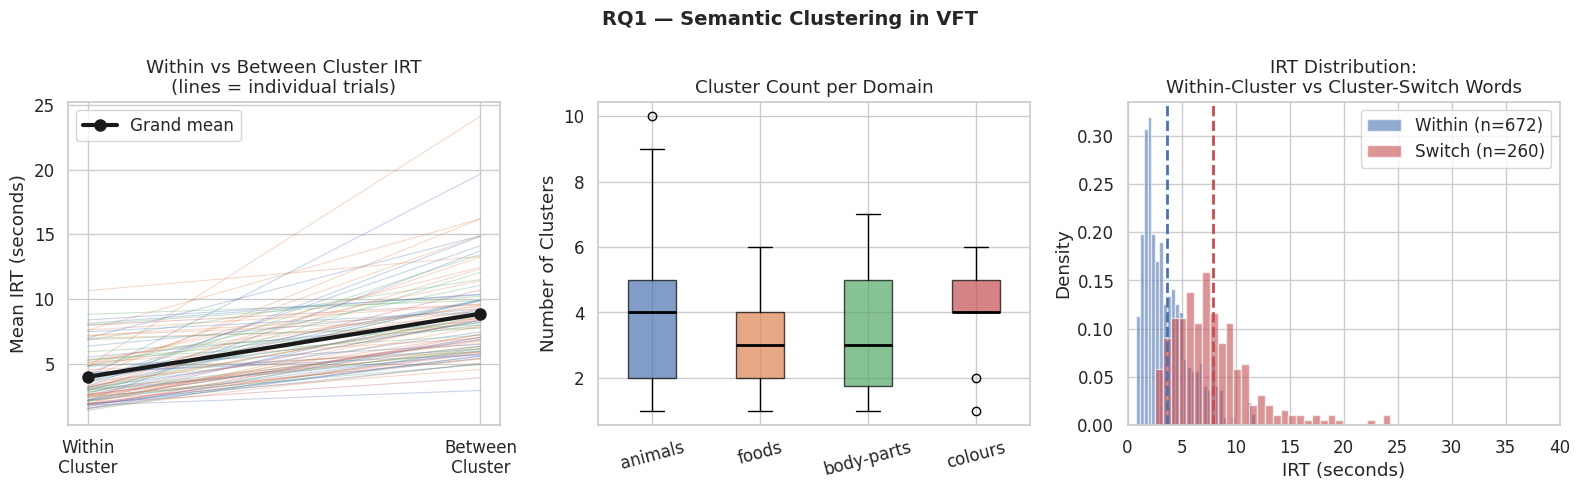

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RQ1 — Semantic Clustering in VFT', fontsize=14, fontweight='bold')

rq1_plot = df_master.dropna(subset=['mean_within_irt','mean_between_irt']).copy()

ax = axes[0]
for _, row in rq1_plot.iterrows():
    ax.plot([1, 2], [row['mean_within_irt']/1000, row['mean_between_irt']/1000],
            color=DOMAIN_COLORS.get(row['domain'],'gray'), alpha=0.3, linewidth=0.8)
means = [rq1_plot['mean_within_irt'].mean()/1000, rq1_plot['mean_between_irt'].mean()/1000]
ax.plot([1,2], means, 'ko-', linewidth=3, markersize=8, label='Grand mean')
ax.set_xticks([1,2]); ax.set_xticklabels(['Within\nCluster','Between\nCluster'])
ax.set_ylabel('Mean IRT (seconds)')
ax.set_title('Within vs Between Cluster IRT\n(lines = individual trials)')
ax.legend()

ax = axes[1]
domain_order = ['animals','foods','body-parts','colours']
data_clust = [df_master[df_master['domain']==d]['n_clusters'].dropna().values for d in domain_order]
bp = ax.boxplot(data_clust, patch_artist=True, medianprops=dict(color='black',linewidth=2))
for patch, d in zip(bp['boxes'], domain_order):
    patch.set_facecolor(DOMAIN_COLORS[d]); patch.set_alpha(0.7)
ax.set_xticklabels(domain_order, rotation=15)
ax.set_ylabel('Number of Clusters'); ax.set_title('Cluster Count per Domain')

ax = axes[2]
non_first = df_vft_clustered[df_vft_clustered['tag'] > 1]
within_all  = non_first[~non_first['is_switch']]['irt_ms'].dropna() / 1000
between_all = non_first[ non_first['is_switch']]['irt_ms'].dropna() / 1000
ax.hist(within_all,  bins=30, alpha=0.6, color='#4C72B0', label=f'Within (n={len(within_all)})', density=True)
ax.hist(between_all, bins=30, alpha=0.6, color='#C44E52', label=f'Switch (n={len(between_all)})', density=True)
ax.axvline(within_all.mean(),  color='#4C72B0', linewidth=2, linestyle='--')
ax.axvline(between_all.mean(), color='#C44E52', linewidth=2, linestyle='--')
ax.set_xlabel('IRT (seconds)'); ax.set_ylabel('Density')
ax.set_title('IRT Distribution:\nWithin-Cluster vs Cluster-Switch Words')
ax.legend(); ax.set_xlim(0, 40)

plt.tight_layout()
plt.savefig('viz_rq1_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

---
## RQ2 — Do faster retrievals reflect tighter semantic neighbourhoods?

### Why Spearman Rank Correlation?
IRT values are highly right-skewed; mean neighbourhood distance also shows non-normal
distribution. Spearman is robust to outliers and tests whether the **rank order** of IRTs
corresponds to rank order of SpAM distances.

### Interpretation note (v3 fix)
`mean_neighbour_dist` is **large** when a word is **far** from all others (isolated).
So a **negative ρ** means: isolated words (high distance) → shorter IRT (recalled faster).
A **positive ρ** would mean: isolated words → longer IRT (the theoretically expected direction).
If ρ < 0, the pattern is counter-theoretical and must be read as: "words in denser SpAM
neighbourhoods (small distance) took **longer** to recall, not shorter."

In [17]:
print('='*65)
print('RQ2: Do faster retrievals reflect tighter semantic neighbourhoods?')
print('='*65)

rq2 = df_cross.dropna(subset=['irt_ms','mean_neighbour_dist']).copy()
rq2 = rq2[rq2['tag'] > 1]   # exclude first word (IRT includes task-loading time)

_, p_irt_norm  = shapiro(rq2['irt_ms'].sample(min(50, len(rq2)), random_state=42))
_, p_dist_norm = shapiro(rq2['mean_neighbour_dist'].sample(min(50, len(rq2)), random_state=42))
print(f'\nNormality (Shapiro-Wilk, sample n=50):')
print(f'  IRT:                p = {p_irt_norm:.4f}  → {"NOT normal" if p_irt_norm < 0.05 else "normal"}')
print(f'  Neighbour distance: p = {p_dist_norm:.4f}  → {"NOT normal" if p_dist_norm < 0.05 else "normal"}')
print(f'  → Primary test: Spearman rank correlation')

rho, p_sp = spearmanr(rq2['irt_ms'], rq2['mean_neighbour_dist'])
r,   p_pe = pearsonr( rq2['irt_ms'], rq2['mean_neighbour_dist'])

print(f'\nWords analysed (tag > 1, matched VFT+SpAM): {len(rq2)}')
print(f'Spearman ρ = {rho:.4f}, p = {p_sp:.4f}  [PRIMARY]')
print(f'Pearson  r = {r:.4f},   p = {p_pe:.4f}  [reference]')

print('\n--- Per domain (Spearman) ---')
for domain in sorted(rq2['domain'].unique()):
    d = rq2[rq2['domain']==domain]
    if len(d) < 5: continue
    rho_d, p_d = spearmanr(d['irt_ms'], d['mean_neighbour_dist'])
    print(f'  {domain:12s}: ρ = {rho_d:.4f}, p = {p_d:.4f}, n = {len(d)}')

print('\n=== INTERPRETATION ===')
print(f'Reminder: mean_neighbour_dist is LARGE for ISOLATED words (far from all others).')
print(f'          Positive ρ = isolated words take LONGER to recall (theory-consistent).')
print(f'          Negative ρ = isolated words recalled FASTER (counter-theoretical).')
print()
if p_sp < 0.05 and rho > 0:
    strength = "weak" if abs(rho)<0.3 else "moderate" if abs(rho)<0.5 else "strong"
    print(f'SUPPORTED: Words placed in more isolated SpAM positions take longer to recall.')
    print(f'Spearman ρ = {rho:.3f} — a {strength} positive association (theory-consistent).')
elif p_sp < 0.05 and rho < 0:
    print(f'NOT SUPPORTED — pattern is OPPOSITE to prediction.')
    print(f'Spearman ρ = {rho:.3f}: words placed farther from SpAM neighbours (more isolated)')
    print(f'are actually recalled FASTER, not slower.')
    print(f'Equivalently: words in DENSER SpAM neighbourhoods (small mean_neighbour_dist) took LONGER.')
    print(f'This contradicts the semantic neighbourhood hypothesis.')
    print(f'Possible explanations: primacy effects (prototypical/easy words placed centrally and recalled first);')
    print(f'  or participants may have deliberately isolated unusual words which were actually highly accessible.')
else:
    print('NOT SUPPORTED: No significant correlation between IRT and SpAM neighbourhood distance.')

RQ2: Do faster retrievals reflect tighter semantic neighbourhoods?

Normality (Shapiro-Wilk, sample n=50):
  IRT:                p = 0.0000  → NOT normal
  Neighbour distance: p = 0.0003  → NOT normal
  → Primary test: Spearman rank correlation

Words analysed (tag > 1, matched VFT+SpAM): 927
Spearman ρ = -0.1753, p = 0.0000  [PRIMARY]
Pearson  r = -0.1205,   p = 0.0002  [reference]

--- Per domain (Spearman) ---
  animals     : ρ = -0.1280, p = 0.0202, n = 329
  body-parts  : ρ = -0.0483, p = 0.5189, n = 181
  colours     : ρ = -0.0326, p = 0.7117, n = 131
  foods       : ρ = -0.1902, p = 0.0012, n = 286

=== INTERPRETATION ===
Reminder: mean_neighbour_dist is LARGE for ISOLATED words (far from all others).
          Positive ρ = isolated words take LONGER to recall (theory-consistent).
          Negative ρ = isolated words recalled FASTER (counter-theoretical).

NOT SUPPORTED — pattern is OPPOSITE to prediction.
Spearman ρ = -0.175: words placed farther from SpAM neighbours (more iso

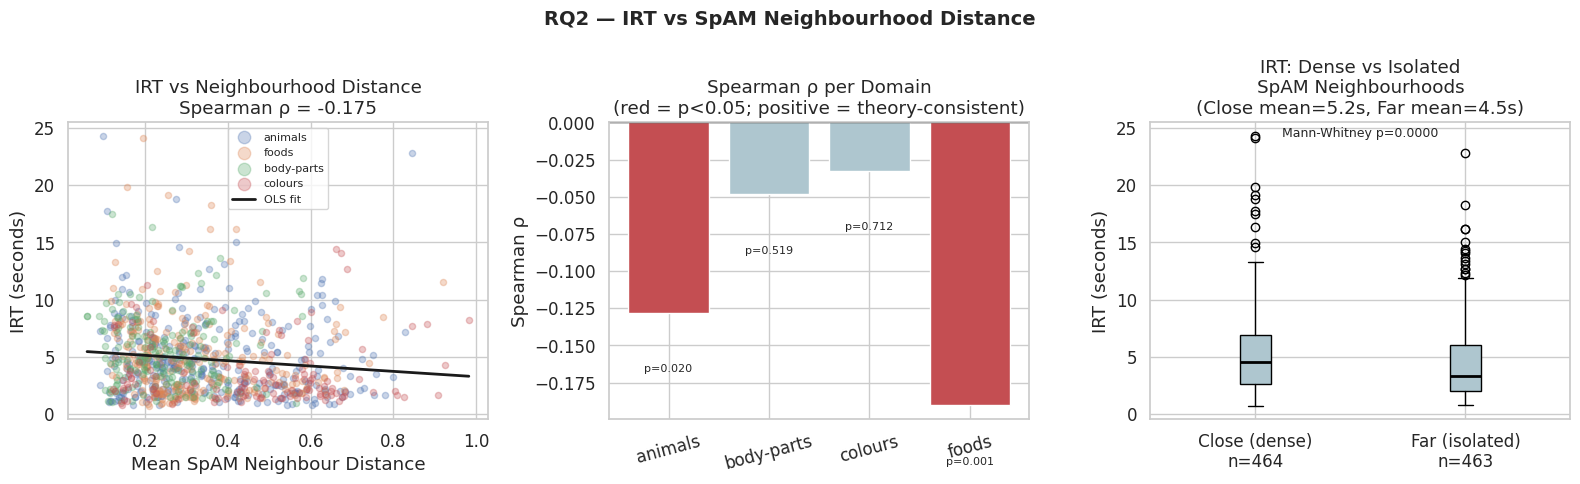

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RQ2 — IRT vs SpAM Neighbourhood Distance', fontsize=14, fontweight='bold')

rq2_plot = df_cross.dropna(subset=['irt_ms','mean_neighbour_dist']).copy()
rq2_plot = rq2_plot[rq2_plot['tag'] > 1]

ax = axes[0]
for d in ['animals','foods','body-parts','colours']:
    sub = rq2_plot[rq2_plot['domain']==d]
    ax.scatter(sub['mean_neighbour_dist'], sub['irt_ms']/1000,
               color=DOMAIN_COLORS[d], alpha=0.3, s=20, label=d)
x = rq2_plot['mean_neighbour_dist'].values
y = rq2_plot['irt_ms'].values / 1000
m, b = np.polyfit(x, y, 1)
xline = np.linspace(x.min(), x.max(), 100)
ax.plot(xline, m*xline+b, 'k-', linewidth=2, label='OLS fit')
rho_all, _ = spearmanr(x, y)
ax.set_xlabel('Mean SpAM Neighbour Distance')
ax.set_ylabel('IRT (seconds)')
ax.set_title(f'IRT vs Neighbourhood Distance\nSpearman ρ = {rho_all:.3f}')
ax.legend(fontsize=8, markerscale=2)

ax = axes[1]
domains_here = sorted(rq2_plot['domain'].unique())
rhos, pvals = [], []
for d in domains_here:
    sub = rq2_plot[rq2_plot['domain']==d]
    if len(sub) < 5: rhos.append(0); pvals.append(1); continue
    rho_d, p_d = spearmanr(sub['irt_ms'], sub['mean_neighbour_dist'])
    rhos.append(rho_d); pvals.append(p_d)
bar_colors = ['#C44E52' if p<0.05 else '#AEC6CF' for p in pvals]
bars = ax.bar(domains_here, rhos, color=bar_colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('Spearman ρ')
ax.set_title('Spearman ρ per Domain\n(red = p<0.05; positive = theory-consistent)')
ax.set_xticklabels(domains_here, rotation=15)
for bar, p in zip(bars, pvals):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.01 if bar.get_height()>=0 else bar.get_height()-0.04,
            f'p={p:.3f}', ha='center', fontsize=8)

ax = axes[2]
median_dist = rq2_plot['mean_neighbour_dist'].median()
close_vals = rq2_plot[rq2_plot['mean_neighbour_dist'] <= median_dist]['irt_ms'].dropna()/1000
far_vals   = rq2_plot[rq2_plot['mean_neighbour_dist'] >  median_dist]['irt_ms'].dropna()/1000
bp = ax.boxplot([close_vals, far_vals], patch_artist=True,
                medianprops=dict(color='black', linewidth=2),
                boxprops=dict(facecolor='#AEC6CF'), positions=[1,2])
ax.set_xticks([1,2])
ax.set_xticklabels([f'Close (dense)\nn={len(close_vals)}', f'Far (isolated)\nn={len(far_vals)}'])
ax.set_ylabel('IRT (seconds)')
ax.set_title(f'IRT: Dense vs Isolated\nSpAM Neighbourhoods\n(Close mean={close_vals.mean():.1f}s, Far mean={far_vals.mean():.1f}s)')
_, p_mw2 = mannwhitneyu(close_vals, far_vals)
ax.text(1.5, ax.get_ylim()[1]*0.95, f'Mann-Whitney p={p_mw2:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('viz_rq2_irt_distance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## RQ3 — Does Hindi fluency predict lexical retrieval efficiency?

### Why Spearman Rank Correlation?
Hindi fluency is a composite Likert-type scale (2–10) — ordinal in nature. Spearman is
appropriate for correlating an ordinal predictor with continuous outcomes.

### Interpretation caution (v3 fix)
If results show counter-theoretical directions (higher fluency → fewer words or slower
retrieval), these must be flagged explicitly. Any discrepancy between the continuous
Spearman result and the median-split Mann-Whitney must also be discussed — a significant
Spearman with a non-significant median-split is a red flag for a spurious correlation,
especially with imbalanced group sizes.

In [19]:
print('='*65)
print('RQ3: Does Hindi fluency predict lexical retrieval efficiency?')
print('='*65)

rq3 = df_master.dropna(subset=['hindi_fluency','word_count','mean_irt_ms','mean_cluster_size'])
fluency = rq3['hindi_fluency'].values

outcomes = {
    'word_count'        : 'Total words recalled',
    'mean_irt_ms'       : 'Mean IRT (ms)',
    'mean_cluster_size' : 'Mean cluster size'
}
# Theoretical expected directions:
expected_positive = {'word_count', 'mean_cluster_size'}   # higher fluency → more words, bigger clusters
expected_negative = {'mean_irt_ms'}                        # higher fluency → shorter IRT

print(f'\nTrials analysed: {len(rq3)}')
print(f'Hindi fluency range: {int(fluency.min())}–{int(fluency.max())}')

results = {}
for col, label in outcomes.items():
    vals = rq3[col].values
    rho, p_sp = spearmanr(fluency, vals)
    r,   p_pe = pearsonr(fluency,  vals)
    results[col] = (rho, p_sp)
    expected_dir = 'positive' if col in expected_positive else 'negative'
    actual_dir   = 'positive' if rho > 0 else 'negative'
    match_flag   = '✓ theory-consistent' if expected_dir == actual_dir else '⚠ COUNTER-THEORETICAL'
    print(f'\n  {label}:')
    print(f'    Spearman ρ = {rho:.4f}, p = {p_sp:.4f}  [PRIMARY]')
    print(f'    Pearson  r = {r:.4f},   p = {p_pe:.4f}  [reference]')
    print(f'    Expected direction: {expected_dir}  |  Actual direction: {actual_dir}  {match_flag}')

# High vs Low fluency group comparison (median split)
med_fl = rq3['hindi_fluency'].median()
hi_fl  = rq3[rq3['hindi_fluency'] > med_fl]
lo_fl  = rq3[rq3['hindi_fluency'] <= med_fl]
print(f'\n--- Median split (threshold={med_fl}): High n={len(hi_fl)}, Low n={len(lo_fl)} ---')
print(f'NOTE: Unequal group sizes can produce spurious Spearman correlations.')
print(f'Compare continuous and median-split results — inconsistency is a red flag.')
for col, label in outcomes.items():
    stat_mw, p_mw = mannwhitneyu(hi_fl[col].dropna(), lo_fl[col].dropna())
    print(f'  {label}: High={hi_fl[col].mean():.1f}, Low={lo_fl[col].mean():.1f}, Mann-Whitney p={p_mw:.4f}')

print('\n=== INTERPRETATION ===')
sig_results = [(col, rho, p) for col, (rho, p) in results.items() if p < 0.05]
any_sig = len(sig_results) > 0

if any_sig:
    print('Significant correlations found. Reading carefully:')
    for col, rho, p in sig_results:
        label = outcomes[col]
        direction = 'positively' if rho > 0 else 'negatively'
        expected_dir = 'positive' if col in expected_positive else 'negative'
        actual_dir   = 'positive' if rho > 0 else 'negative'
        if expected_dir == actual_dir:
            print(f'✓ SUPPORTED: Hindi fluency {direction} predicts {label} (ρ={rho:.3f}, p={p:.4f})')
            print(f'  Interpretation: Higher Hindi fluency is associated with better retrieval on this measure.')
        else:
            print(f'⚠ COUNTER-THEORETICAL: Hindi fluency {direction} predicts {label} (ρ={rho:.3f}, p={p:.4f})')
            print(f'  This goes AGAINST the expected direction. Higher fluency participants show')
            if col == 'mean_irt_ms':
                print(f'  SLOWER retrieval (longer IRT), which is the opposite of what fluency predicts.')
            elif col == 'word_count':
                print(f'  FEWER words recalled, which contradicts the fluency-as-richness hypothesis.')
            print(f'  ⚠ CHECK median-split result above: if it is non-significant, this Spearman')
            print(f'    result may be a spurious artefact of group size imbalance.')
            print(f'  Treat with caution; do not interpret as a genuine fluency effect.')
else:
    print('NOT SUPPORTED: Hindi fluency does not significantly predict any retrieval outcome.')
    print('Possible explanation: All participants met Hindi comfort criteria, so fluency')
    print('variation may be too narrow to detect meaningful differences.')

RQ3: Does Hindi fluency predict lexical retrieval efficiency?

Trials analysed: 105
Hindi fluency range: 4–10

  Total words recalled:
    Spearman ρ = -0.2003, p = 0.0405  [PRIMARY]
    Pearson  r = -0.1496,   p = 0.1276  [reference]
    Expected direction: positive  |  Actual direction: negative  ⚠ COUNTER-THEORETICAL

  Mean IRT (ms):
    Spearman ρ = 0.2756, p = 0.0044  [PRIMARY]
    Pearson  r = 0.2774,   p = 0.0042  [reference]
    Expected direction: negative  |  Actual direction: positive  ⚠ COUNTER-THEORETICAL

  Mean cluster size:
    Spearman ρ = 0.1631, p = 0.0964  [PRIMARY]
    Pearson  r = 0.1498,   p = 0.1271  [reference]
    Expected direction: positive  |  Actual direction: positive  ✓ theory-consistent

--- Median split (threshold=8.0): High n=30, Low n=75 ---
NOTE: Unequal group sizes can produce spurious Spearman correlations.
Compare continuous and median-split results — inconsistency is a red flag.
  Total words recalled: High=9.9, Low=9.9, Mann-Whitney p=0.5804
 

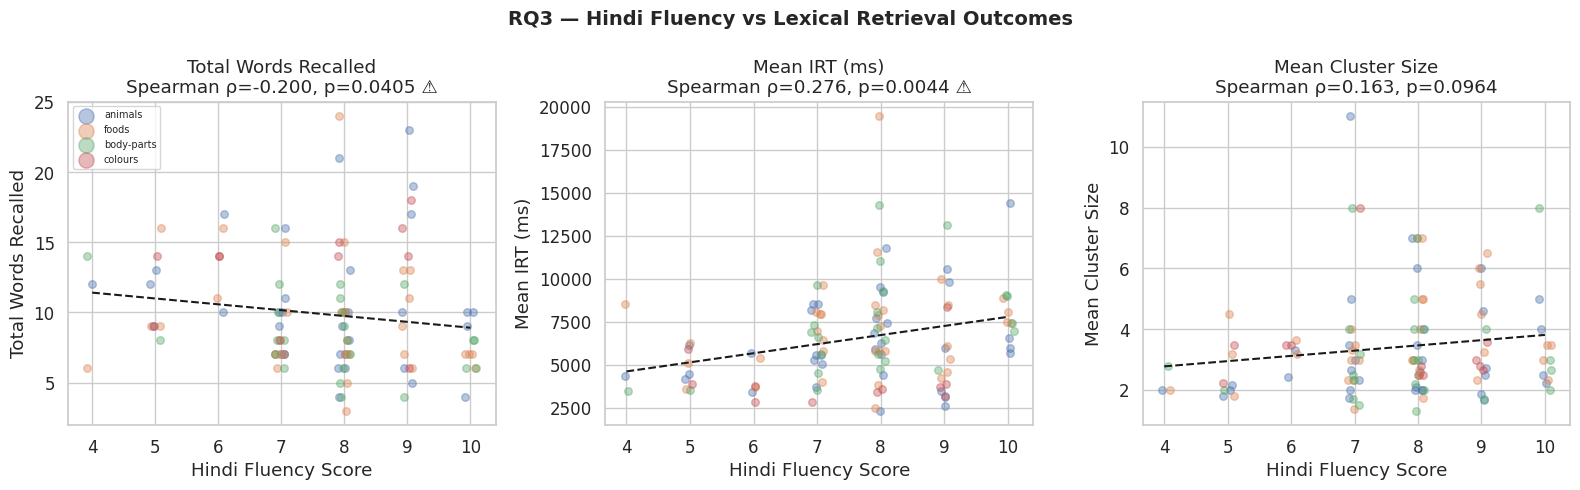

⚠ = result goes in counter-theoretical direction; interpret with caution.


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RQ3 — Hindi Fluency vs Lexical Retrieval Outcomes', fontsize=14, fontweight='bold')

rq3_plot = df_master.dropna(subset=['hindi_fluency','word_count','mean_irt_ms','mean_cluster_size'])
outcomes_plot = [('word_count','Total Words Recalled'),
                 ('mean_irt_ms','Mean IRT (ms)'),
                 ('mean_cluster_size','Mean Cluster Size')]

for ax, (col, label) in zip(axes, outcomes_plot):
    for d in ['animals','foods','body-parts','colours']:
        sub = rq3_plot[rq3_plot['domain']==d].dropna(subset=[col])
        jitter = np.random.uniform(-0.1,0.1,len(sub))
        ax.scatter(sub['hindi_fluency']+jitter, sub[col],
                   color=DOMAIN_COLORS[d], alpha=0.4, s=30, label=d)
    x_clean = rq3_plot.dropna(subset=[col])['hindi_fluency'].values
    y_clean = rq3_plot.dropna(subset=[col])[col].values
    m, b = np.polyfit(x_clean, y_clean, 1)
    xline = np.linspace(x_clean.min(), x_clean.max(), 100)
    ax.plot(xline, m*xline+b, 'k--', linewidth=1.5)
    rho, p = spearmanr(x_clean, y_clean)
    dir_flag = '' if (rho>0 and col!='mean_irt_ms') or (rho<0 and col=='mean_irt_ms') else ' ⚠'
    ax.set_xlabel('Hindi Fluency Score')
    ax.set_ylabel(label)
    ax.set_title(f'{label}\nSpearman ρ={rho:.3f}, p={p:.4f}{dir_flag}')
    if ax == axes[0]: ax.legend(fontsize=7, markerscale=2)

plt.tight_layout()
plt.savefig('viz_rq3_fluency.png', dpi=150, bbox_inches='tight')
plt.show()
print('⚠ = result goes in counter-theoretical direction; interpret with caution.')

---
## RQ4 — Does the order of domains within a session affect retrieval performance?

### Why Kruskal-Wallis Test?
Three independent groups (session positions 1, 2, 3) with non-normal data.
Kruskal-Wallis is the non-parametric equivalent of one-way ANOVA.
Post-hoc: pairwise Mann-Whitney U with Bonferroni correction (α = 0.017).

In [21]:
print('='*65)
print('RQ4: Does domain order within a session affect retrieval performance?')
print('='*65)

rq4 = df_master.dropna(subset=['session_pos','word_count','mean_irt_ms'])

print(f'\nTrials analysed: {len(rq4)}')
for pos in [1,2,3]:
    sub = rq4[rq4['session_pos']==pos]
    print(f'  Position {pos}: n={len(sub)}, mean words={sub["word_count"].mean():.2f}, '
          f'mean IRT={sub["mean_irt_ms"].mean():.0f}ms')

print('\nNormality (Shapiro-Wilk):')
for pos in [1,2,3]:
    vals = rq4[rq4['session_pos']==pos]['word_count'].values
    if len(vals) >= 3:
        _, p_n = shapiro(vals)
        print(f'  Position {pos} word_count: p = {p_n:.4f}  → {"NOT normal" if p_n<0.05 else "normal"}')

groups_wc  = [rq4[rq4['session_pos']==p]['word_count'].values  for p in [1,2,3]]
groups_irt = [rq4[rq4['session_pos']==p]['mean_irt_ms'].values for p in [1,2,3]]
h_wc,  p_wc  = kruskal(*groups_wc)
h_irt, p_irt = kruskal(*groups_irt)

print(f'\nKruskal-Wallis — Word Count: H = {h_wc:.3f}, p = {p_wc:.4f}')
print(f'Kruskal-Wallis — Mean IRT  : H = {h_irt:.3f}, p = {p_irt:.4f}')

for metric, groups, p_main, label in [
    ('word_count',  groups_wc,  p_wc,  'Word Count'),
    ('mean_irt_ms', groups_irt, p_irt, 'Mean IRT')
]:
    if p_main < 0.05:
        print(f'\nPost-hoc pairwise Mann-Whitney U ({label}) — Bonferroni α=0.017:')
        for p1, p2 in [(1,2),(1,3),(2,3)]:
            g1 = rq4[rq4['session_pos']==p1][metric].values
            g2 = rq4[rq4['session_pos']==p2][metric].values
            stat, p_pair = mannwhitneyu(g1, g2)
            sig = '* SIGNIFICANT' if p_pair < 0.017 else ''
            print(f'  Pos {p1} vs Pos {p2}: U={stat:.1f}, p={p_pair:.4f} {sig}')

print('\n=== INTERPRETATION ===')
if p_wc < 0.05 or p_irt < 0.05:
    sig_metric = 'word count' if p_wc < 0.05 else 'mean IRT'
    print(f'SIGNIFICANT effect of session order on {sig_metric}.')
    print('Warm-up, fatigue, or carryover between domains may explain this.')
else:
    print('NOT SUPPORTED: Session order does not significantly affect retrieval performance.')
    print('Domain order within the session does not produce systematic warm-up or fatigue.')

RQ4: Does domain order within a session affect retrieval performance?

Trials analysed: 93
  Position 1: n=31, mean words=9.74, mean IRT=6701ms
  Position 2: n=31, mean words=9.74, mean IRT=6450ms
  Position 3: n=31, mean words=10.77, mean IRT=6209ms

Normality (Shapiro-Wilk):
  Position 1 word_count: p = 0.0039  → NOT normal
  Position 2 word_count: p = 0.0023  → NOT normal
  Position 3 word_count: p = 0.1976  → normal

Kruskal-Wallis — Word Count: H = 2.045, p = 0.3597
Kruskal-Wallis — Mean IRT  : H = 0.934, p = 0.6270

=== INTERPRETATION ===
NOT SUPPORTED: Session order does not significantly affect retrieval performance.
Domain order within the session does not produce systematic warm-up or fatigue.


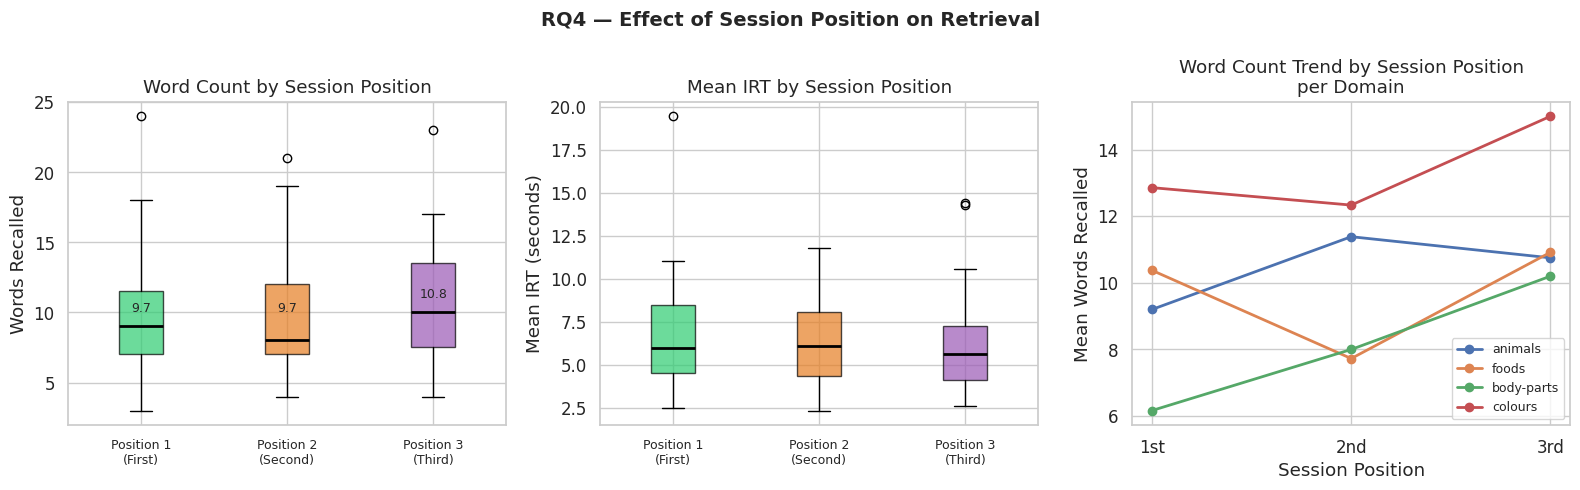

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RQ4 — Effect of Session Position on Retrieval', fontsize=14, fontweight='bold')

rq4_plot = df_master.dropna(subset=['session_pos','word_count','mean_irt_ms'])
positions  = [1, 2, 3]
pos_labels = ['Position 1\n(First)', 'Position 2\n(Second)', 'Position 3\n(Third)']
colors_pos = ['#2ecc71','#e67e22','#9b59b6']

ax = axes[0]
data_wc = [rq4_plot[rq4_plot['session_pos']==p]['word_count'].values for p in positions]
bp = ax.boxplot(data_wc, patch_artist=True, medianprops=dict(color='black',linewidth=2))
for patch, c in zip(bp['boxes'], colors_pos):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_xticklabels(pos_labels, fontsize=9); ax.set_ylabel('Words Recalled')
ax.set_title('Word Count by Session Position')
for i, data in enumerate(data_wc, start=1):
    ax.text(i, np.mean(data)+0.3, f'{np.mean(data):.1f}', ha='center', fontsize=9)

ax = axes[1]
data_irt = [rq4_plot[rq4_plot['session_pos']==p]['mean_irt_ms'].values/1000 for p in positions]
bp2 = ax.boxplot(data_irt, patch_artist=True, medianprops=dict(color='black',linewidth=2))
for patch, c in zip(bp2['boxes'], colors_pos):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_xticklabels(pos_labels, fontsize=9); ax.set_ylabel('Mean IRT (seconds)')
ax.set_title('Mean IRT by Session Position')

ax = axes[2]
for d in ['animals','foods','body-parts','colours']:
    sub = rq4_plot[rq4_plot['domain']==d].groupby('session_pos')['word_count'].mean()
    if len(sub) > 1:
        ax.plot(sub.index, sub.values, 'o-', color=DOMAIN_COLORS[d], label=d, linewidth=2)
ax.set_xticks([1,2,3]); ax.set_xticklabels(['1st','2nd','3rd'])
ax.set_xlabel('Session Position'); ax.set_ylabel('Mean Words Recalled')
ax.set_title('Word Count Trend by Session Position\nper Domain')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('viz_rq4_session_order.png', dpi=150, bbox_inches='tight')
plt.show()

---
## RQ5 — Do people pause longer before typing a word they place far from others in SpAM?

### Why Spearman Rank Correlation + Mann-Whitney U?
Both IRT and SpAM distance are non-normally distributed. Spearman tests the continuous
relationship; Mann-Whitney tests the close vs far split.

### Interpretation fix (v3)
`mean_neighbour_dist` is large for **isolated** words (far from all others).
The hypothesis predicts: isolated words (large distance) → longer IRT (positive ρ).
If ρ is negative AND the median split shows close words have longer IRTs than far words,
the pattern is **opposite** to the prediction. Both pieces of evidence must agree.

In [23]:
print('='*65)
print('RQ5: Do people pause longer before words placed far from others?')
print('='*65)

rq5 = df_cross.dropna(subset=['irt_ms','centroid_dist','mean_neighbour_dist']).copy()
rq5 = rq5[rq5['tag'] > 1]

rho_nb, p_nb = spearmanr(rq5['irt_ms'], rq5['mean_neighbour_dist'])
rho_cd, p_cd = spearmanr(rq5['irt_ms'], rq5['centroid_dist'])

print(f'\nWords analysed: {len(rq5)}')
print(f'\nIRT vs Mean Neighbour Distance: ρ = {rho_nb:.4f}, p = {p_nb:.4f}')
print(f'IRT vs Centroid Distance       : ρ = {rho_cd:.4f}, p = {p_cd:.4f}')
print(f'(Positive ρ = isolated/far words take longer — theory-consistent)')

# Median split — Mann-Whitney U
median_nb = rq5['mean_neighbour_dist'].median()
close = rq5[rq5['mean_neighbour_dist'] <= median_nb]['irt_ms'].dropna()
far   = rq5[rq5['mean_neighbour_dist'] >  median_nb]['irt_ms'].dropna()
stat_mw, p_mw = mannwhitneyu(close, far)

print(f'\nMedian split on mean_neighbour_dist (threshold={median_nb:.3f}):')
print(f'  Close words (dense neighbourhood)  n={len(close)}: mean IRT = {close.mean():.1f} ms')
print(f'  Far words (isolated neighbourhood) n={len(far)}: mean IRT = {far.mean():.1f} ms')
print(f'  Mann-Whitney U = {stat_mw:.1f}, p = {p_mw:.4f}')

print('\n=== INTERPRETATION ===')
close_longer = close.mean() > far.mean()
consistent_with_rho = (rho_nb < 0 and close_longer) or (rho_nb > 0 and not close_longer)

if p_nb < 0.05 and rho_nb > 0:
    print(f'SUPPORTED: Words placed in more isolated SpAM positions take longer to recall.')
    print(f'ρ = {rho_nb:.3f} — consistent with hypothesis. Denser neighbourhood → faster retrieval.')
elif p_nb < 0.05 and rho_nb < 0:
    print(f'NOT SUPPORTED — pattern is OPPOSITE to prediction.')
    print(f'Spearman ρ = {rho_nb:.3f}: isolated words are recalled FASTER, not slower.')
    print(f'Median split confirms this: Close={close.mean():.0f}ms vs Far={far.mean():.0f}ms.')
    if close_longer:
        print(f'  → Words in DENSER (close) neighbourhoods took LONGER to retrieve.')
    print(f'  The hypothesis predicts the opposite. Do not interpret as partially supported.')
    if p_mw < 0.05:
        print(f'  Mann-Whitney is significant (p={p_mw:.4f}) but the direction is counter-theoretical.')
        print(f'  Significance here reinforces the OPPOSITE of what was predicted.')
else:
    print('NOT SUPPORTED: No significant relationship between SpAM isolation and retrieval time.')

RQ5: Do people pause longer before words placed far from others?

Words analysed: 927

IRT vs Mean Neighbour Distance: ρ = -0.1753, p = 0.0000
IRT vs Centroid Distance       : ρ = -0.1300, p = 0.0001
(Positive ρ = isolated/far words take longer — theory-consistent)

Median split on mean_neighbour_dist (threshold=0.296):
  Close words (dense neighbourhood)  n=464: mean IRT = 5180.6 ms
  Far words (isolated neighbourhood) n=463: mean IRT = 4450.6 ms
  Mann-Whitney U = 124466.5, p = 0.0000

=== INTERPRETATION ===
NOT SUPPORTED — pattern is OPPOSITE to prediction.
Spearman ρ = -0.175: isolated words are recalled FASTER, not slower.
Median split confirms this: Close=5181ms vs Far=4451ms.
  → Words in DENSER (close) neighbourhoods took LONGER to retrieve.
  The hypothesis predicts the opposite. Do not interpret as partially supported.
  Mann-Whitney is significant (p=0.0000) but the direction is counter-theoretical.
  Significance here reinforces the OPPOSITE of what was predicted.


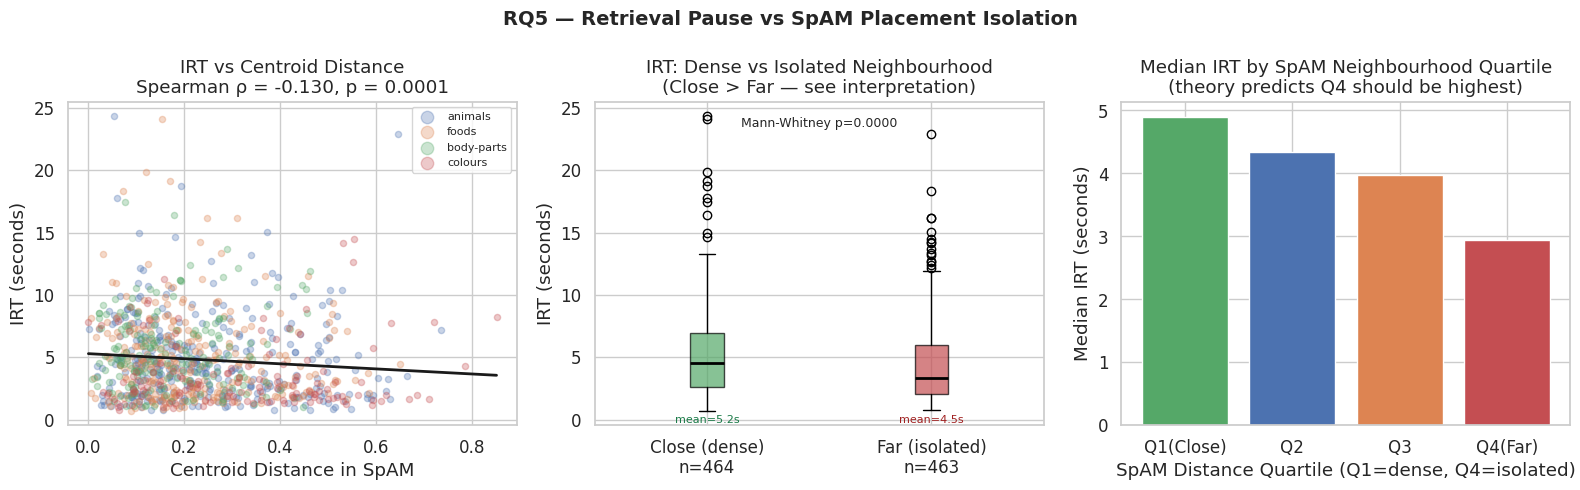

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RQ5 — Retrieval Pause vs SpAM Placement Isolation', fontsize=14, fontweight='bold')

ax = axes[0]
for d in ['animals','foods','body-parts','colours']:
    sub = rq5[rq5['domain']==d]
    ax.scatter(sub['centroid_dist'], sub['irt_ms']/1000,
               color=DOMAIN_COLORS[d], alpha=0.3, s=20, label=d)
x = rq5['centroid_dist'].values; y = rq5['irt_ms'].values / 1000
m, b = np.polyfit(x, y, 1)
ax.plot(np.linspace(x.min(),x.max(),100), m*np.linspace(x.min(),x.max(),100)+b, 'k-', linewidth=2)
rho_p, p_p = spearmanr(x, y)
ax.set_xlabel('Centroid Distance in SpAM'); ax.set_ylabel('IRT (seconds)')
ax.set_title(f'IRT vs Centroid Distance\nSpearman ρ = {rho_p:.3f}, p = {p_p:.4f}')
ax.legend(fontsize=8, markerscale=2)

ax = axes[1]
close_p = rq5[rq5['mean_neighbour_dist'] <= rq5['mean_neighbour_dist'].median()]['irt_ms']/1000
far_p   = rq5[rq5['mean_neighbour_dist'] >  rq5['mean_neighbour_dist'].median()]['irt_ms']/1000
bp = ax.boxplot([close_p, far_p], patch_artist=True, medianprops=dict(color='black',linewidth=2))
bp['boxes'][0].set_facecolor('#55A868'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#C44E52'); bp['boxes'][1].set_alpha(0.7)
ax.set_xticklabels([f'Close (dense)\nn={len(close_p)}', f'Far (isolated)\nn={len(far_p)}'])
ax.set_ylabel('IRT (seconds)')
_, p_mw2 = mannwhitneyu(close_p, far_p)
direction_note = 'Close > Far' if close_p.mean() > far_p.mean() else 'Far > Close'
ax.set_title(f'IRT: Dense vs Isolated Neighbourhood\n({direction_note} — see interpretation)')
ax.text(1.5, ax.get_ylim()[1]*0.92, f'Mann-Whitney p={p_mw2:.4f}', ha='center', fontsize=9)
ax.text(1, ax.get_ylim()[0]+0.2, f'mean={close_p.mean():.1f}s', ha='center', fontsize=8, color='#1a7a47')
ax.text(2, ax.get_ylim()[0]+0.2, f'mean={far_p.mean():.1f}s',   ha='center', fontsize=8, color='#a02020')

ax = axes[2]
rq5_copy = rq5.copy()
rq5_copy['dist_quartile'] = pd.qcut(rq5_copy['mean_neighbour_dist'], q=4,
                                    labels=['Q1(Close)','Q2','Q3','Q4(Far)'])
quartile_means = rq5_copy.groupby('dist_quartile', observed=True)['irt_ms'].median() / 1000
ax.bar(quartile_means.index, quartile_means.values,
       color=['#55A868','#4C72B0','#DD8452','#C44E52'], edgecolor='white')
ax.set_xlabel('SpAM Distance Quartile (Q1=dense, Q4=isolated)')
ax.set_ylabel('Median IRT (seconds)')
ax.set_title('Median IRT by SpAM Neighbourhood Quartile\n(theory predicts Q4 should be highest)')

plt.tight_layout()
plt.savefig('viz_rq5_isolation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## RQ6 — Do people who type more words in VFT also take less time to arrange them in SpAM?

### Why Spearman + Efficiency-Adjusted Metric?
More words → more drag operations, so raw SpAM RT will increase trivially with word count.
We use **SpAM seconds per word** as the efficiency metric. A negative correlation between
word count and sec/word means higher-fluency participants are faster per word.

In [25]:
print('='*65)
print('RQ6: More VFT words → less SpAM arrangement time per word?')
print('='*65)

rq6 = df_master.dropna(subset=['word_count','spam_rt_sec']).copy()
rq6['spam_sec_per_word'] = rq6['spam_rt_sec'] / rq6['word_count']

rho_raw, p_raw = spearmanr(rq6['word_count'], rq6['spam_rt_sec'])
rho_adj, p_adj = spearmanr(rq6['word_count'], rq6['spam_sec_per_word'])

print(f'\nTrials analysed: {len(rq6)}')
print(f'\nWord count vs raw SpAM RT (trivially confounded):')
print(f'  Spearman ρ = {rho_raw:.4f}, p = {p_raw:.4f}')
print(f'  (Expected positive — more words = more dragging time)')

print(f'\nWord count vs SpAM seconds per word (efficiency-adjusted):')
print(f'  Spearman ρ = {rho_adj:.4f}, p = {p_adj:.4f}')
print(f'  (Negative = high-fluency participants are FASTER per word)')

print('\n--- Per domain ---')
for d in sorted(rq6['domain'].unique()):
    sub = rq6[rq6['domain']==d]
    if len(sub) < 5: continue
    rho_d, p_d = spearmanr(sub['word_count'], sub['spam_sec_per_word'])
    print(f'  {d:12s}: ρ = {rho_d:.4f}, p = {p_d:.4f}, n = {len(sub)}')

print('\n=== INTERPRETATION ===')
if p_adj < 0.05 and rho_adj < 0:
    print(f'SUPPORTED: Participants with more VFT words spend LESS time per word in SpAM.')
    print(f'ρ = {rho_adj:.3f} — greater lexical fluency → faster, more decisive spatial organisation.')
elif p_adj < 0.05 and rho_adj > 0:
    print(f'OPPOSITE: More words → more time per word in SpAM.')
    print('Richer vocabulary may require more deliberation when organising many semantically distinct items.')
else:
    print('NOT SUPPORTED: VFT word count does not predict SpAM time efficiency.')

RQ6: More VFT words → less SpAM arrangement time per word?

Trials analysed: 105

Word count vs raw SpAM RT (trivially confounded):
  Spearman ρ = 0.5782, p = 0.0000
  (Expected positive — more words = more dragging time)

Word count vs SpAM seconds per word (efficiency-adjusted):
  Spearman ρ = -0.3523, p = 0.0002
  (Negative = high-fluency participants are FASTER per word)

--- Per domain ---
  animals     : ρ = -0.2978, p = 0.0823, n = 35
  body-parts  : ρ = -0.3193, p = 0.1283, n = 24
  colours     : ρ = -0.6579, p = 0.0278, n = 11
  foods       : ρ = -0.4994, p = 0.0023, n = 35

=== INTERPRETATION ===
SUPPORTED: Participants with more VFT words spend LESS time per word in SpAM.
ρ = -0.352 — greater lexical fluency → faster, more decisive spatial organisation.


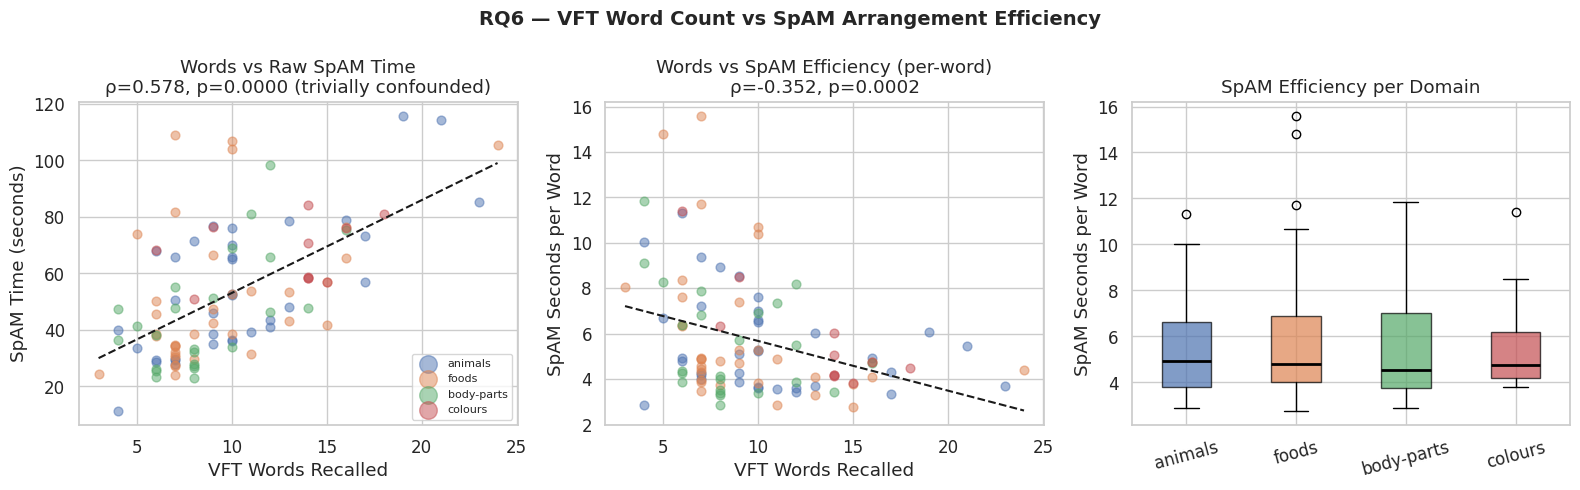

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RQ6 — VFT Word Count vs SpAM Arrangement Efficiency', fontsize=14, fontweight='bold')

rq6_plot = df_master.dropna(subset=['word_count','spam_rt_sec']).copy()
rq6_plot['spam_sec_per_word'] = rq6_plot['spam_rt_sec'] / rq6_plot['word_count']

ax = axes[0]
for d in ['animals','foods','body-parts','colours']:
    sub = rq6_plot[rq6_plot['domain']==d]
    ax.scatter(sub['word_count'], sub['spam_rt_sec'], color=DOMAIN_COLORS[d], alpha=0.5, s=40, label=d)
x = rq6_plot['word_count'].values; y = rq6_plot['spam_rt_sec'].values
m,b = np.polyfit(x, y, 1)
ax.plot(np.linspace(x.min(),x.max(),100), m*np.linspace(x.min(),x.max(),100)+b, 'k--', linewidth=1.5)
rho_r, p_r = spearmanr(x, y)
ax.set_xlabel('VFT Words Recalled'); ax.set_ylabel('SpAM Time (seconds)')
ax.set_title(f'Words vs Raw SpAM Time\nρ={rho_r:.3f}, p={p_r:.4f} (trivially confounded)')
ax.legend(fontsize=8, markerscale=2)

ax = axes[1]
for d in ['animals','foods','body-parts','colours']:
    sub = rq6_plot[rq6_plot['domain']==d]
    ax.scatter(sub['word_count'], sub['spam_sec_per_word'], color=DOMAIN_COLORS[d], alpha=0.5, s=40)
x2 = rq6_plot['word_count'].values; y2 = rq6_plot['spam_sec_per_word'].values
m2,b2 = np.polyfit(x2, y2, 1)
ax.plot(np.linspace(x2.min(),x2.max(),100), m2*np.linspace(x2.min(),x2.max(),100)+b2, 'k--', linewidth=1.5)
rho_a, p_a = spearmanr(x2, y2)
ax.set_xlabel('VFT Words Recalled'); ax.set_ylabel('SpAM Seconds per Word')
ax.set_title(f'Words vs SpAM Efficiency (per-word)\nρ={rho_a:.3f}, p={p_a:.4f}')

ax = axes[2]
domain_order = ['animals','foods','body-parts','colours']
data_eff = [rq6_plot[rq6_plot['domain']==d]['spam_sec_per_word'].values for d in domain_order]
bp = ax.boxplot(data_eff, patch_artist=True, medianprops=dict(color='black',linewidth=2))
for patch, d in zip(bp['boxes'], domain_order):
    patch.set_facecolor(DOMAIN_COLORS[d]); patch.set_alpha(0.7)
ax.set_xticklabels(domain_order, rotation=15)
ax.set_ylabel('SpAM Seconds per Word'); ax.set_title('SpAM Efficiency per Domain')

plt.tight_layout()
plt.savefig('viz_rq6_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

---
## RQ7 — Does the first word typed in VFT tend to be placed at the centre of the SpAM canvas?

### Why Mann-Whitney U Test?
Two independent groups (first-recalled vs other words), non-normal distribution of distances.
Mann-Whitney U is the non-parametric independent-samples comparison.

### Primary vs Ancillary tests (v3 fix)
The **primary test** is distance from the **group centroid** — this captures whether the first
word is the semantic prototype (surrounded by others). Distance from the canvas centre (0.5, 0.5)
is an **ancillary** test, since canvas centre reflects layout preference, not semantic centrality.
The group centroid result is reported first and drives the conclusion.

In [27]:
print('='*65)
print('RQ7: Is the first VFT word placed centrally in SpAM?')
print('='*65)

rq7 = df_cross.dropna(subset=['centroid_dist','x_norm','y_norm']).copy()
rq7['dist_canvas_centre'] = np.sqrt((rq7['x_norm']-0.5)**2 + (rq7['y_norm']-0.5)**2)

first = rq7[rq7['tag'] == 1]
other = rq7[rq7['tag'] >  1]

_, p_fn = shapiro(first['centroid_dist'].values)
_, p_on = shapiro(other['centroid_dist'].sample(min(50, len(other)), random_state=42).values)
print(f'\nShapiro-Wilk normality:')
print(f'  First words centroid_dist: p = {p_fn:.4f}  → {"NOT normal" if p_fn<0.05 else "normal"}')
print(f'  Other words centroid_dist: p = {p_on:.4f}  → {"NOT normal" if p_on<0.05 else "normal"}')
print(f'  → Primary test: Mann-Whitney U')

# PRIMARY: Distance from group centroid
stat_cd, p_cd = mannwhitneyu(first['centroid_dist'], other['centroid_dist'])

# ANCILLARY: Distance from canvas centre
stat_cc, p_cc = mannwhitneyu(first['dist_canvas_centre'], other['dist_canvas_centre'])

print(f'\nFirst words n = {len(first)}, Other words n = {len(other)}')

print(f'\n[PRIMARY] Distance from GROUP CENTROID:')
print(f'  First words: mean = {first["centroid_dist"].mean():.4f}')
print(f'  Other words: mean = {other["centroid_dist"].mean():.4f}')
print(f'  Mann-Whitney U = {stat_cd:.1f}, p = {p_cd:.4f}')

print(f'\n[ANCILLARY] Distance from CANVAS CENTRE (0.5, 0.5):')
print(f'  First words: mean = {first["dist_canvas_centre"].mean():.4f}')
print(f'  Other words: mean = {other["dist_canvas_centre"].mean():.4f}')
print(f'  Mann-Whitney U = {stat_cc:.1f}, p = {p_cc:.4f}')

print('\n--- Per domain (GROUP CENTROID, primary) ---')
for d in sorted(rq7['domain'].unique()):
    sub = rq7[rq7['domain']==d]
    fw = sub[sub['tag']==1]['centroid_dist']
    ow = sub[sub['tag']> 1]['centroid_dist']
    if len(fw)<3 or len(ow)<3: continue
    stat_d, p_d = mannwhitneyu(fw, ow)
    print(f'  {d:12s}: first={fw.mean():.4f}, others={ow.mean():.4f}, U={stat_d:.1f}, p={p_d:.4f}')

print('\n=== INTERPRETATION (primary = group centroid) ===')
if p_cd < 0.05 and first['centroid_dist'].mean() < other['centroid_dist'].mean():
    print('SUPPORTED: First-recalled words are placed significantly closer to the group centroid.')
    print('This supports the prototype hypothesis — first word recalled is the semantic core.')
elif p_cd < 0.05 and first['centroid_dist'].mean() > other['centroid_dist'].mean():
    print('OPPOSITE (group centroid): First words are placed FARTHER from the group centroid.')
    print('First-recalled words sit at the periphery of the semantic arrangement, not the centre.')
else:
    print('NOT SUPPORTED (group centroid): First words are not placed more centrally by semantic group.')
    print('The prototype hypothesis is not supported.')

# Ancillary canvas centre result — always report separately
print(f'\n--- Ancillary finding (canvas centre) ---')
if p_cc < 0.05:
    if first['dist_canvas_centre'].mean() > other['dist_canvas_centre'].mean():
        print('Ancillary: First words placed FARTHER from canvas centre than other words (p={p_cc:.4f}).')
        print('This reflects a layout preference (anchoring first word at edges) — not semantic centrality.')
    else:
        print(f'Ancillary: First words placed CLOSER to canvas centre than others (p={p_cc:.4f}).')
        print('Canvas centre finding may reflect layout preference rather than semantic centrality.')
else:
    print(f'Ancillary (canvas centre): Not significant (p={p_cc:.4f}).')

RQ7: Is the first VFT word placed centrally in SpAM?

Shapiro-Wilk normality:
  First words centroid_dist: p = 0.0000  → NOT normal
  Other words centroid_dist: p = 0.0001  → NOT normal
  → Primary test: Mann-Whitney U

First words n = 105, Other words n = 927

[PRIMARY] Distance from GROUP CENTROID:
  First words: mean = 0.2498
  Other words: mean = 0.2342
  Mann-Whitney U = 51767.5, p = 0.2843

[ANCILLARY] Distance from CANVAS CENTRE (0.5, 0.5):
  First words: mean = 0.3613
  Other words: mean = 0.3106
  Mann-Whitney U = 58185.0, p = 0.0010

--- Per domain (GROUP CENTROID, primary) ---
  animals     : first=0.2615, others=0.2461, U=6094.0, p=0.5702
  body-parts  : first=0.1876, others=0.1744, U=2358.0, p=0.4970
  colours     : first=0.3090, others=0.3199, U=720.0, p=1.0000
  foods       : first=0.2621, others=0.2191, U=5718.5, p=0.1689

=== INTERPRETATION (primary = group centroid) ===
NOT SUPPORTED (group centroid): First words are not placed more centrally by semantic group.
The pr

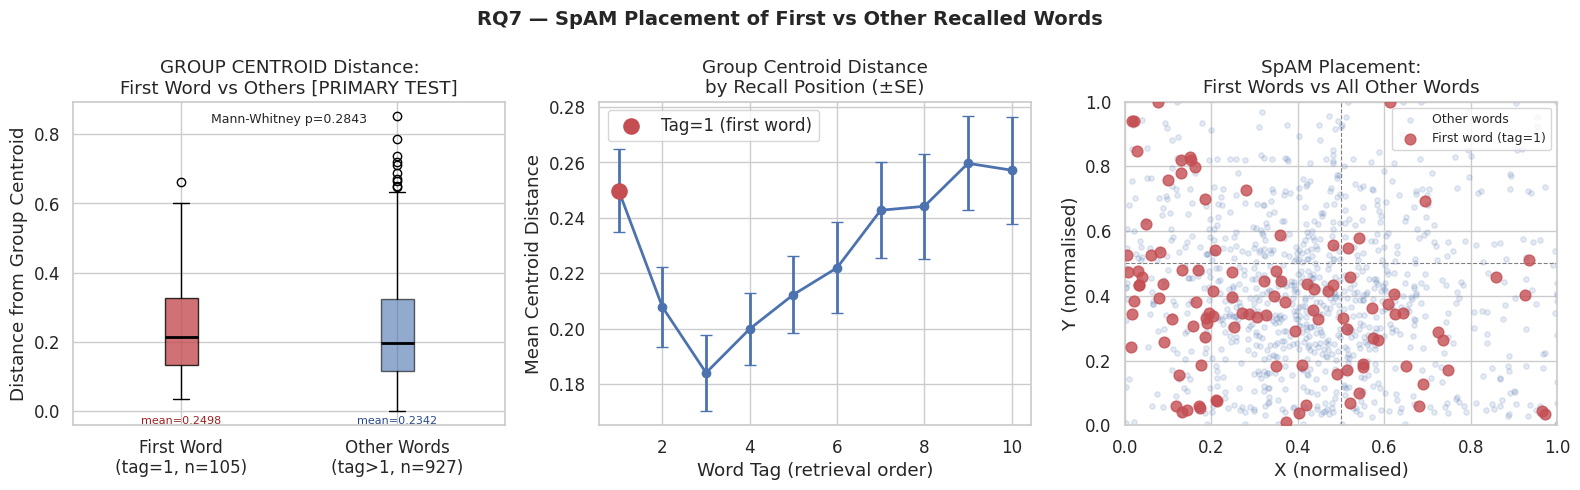

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RQ7 — SpAM Placement of First vs Other Recalled Words', fontsize=14, fontweight='bold')

ax = axes[0]
first_p = rq7[rq7['tag']==1]['centroid_dist']
other_p = rq7[rq7['tag']> 1]['centroid_dist']
bp = ax.boxplot([first_p, other_p], patch_artist=True, medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#C44E52'); bp['boxes'][0].set_alpha(0.8)
bp['boxes'][1].set_facecolor('#4C72B0'); bp['boxes'][1].set_alpha(0.6)
ax.set_xticklabels([f'First Word\n(tag=1, n={len(first_p)})',
                    f'Other Words\n(tag>1, n={len(other_p)})'])
ax.set_ylabel('Distance from Group Centroid')
ax.set_title('GROUP CENTROID Distance:\nFirst Word vs Others [PRIMARY TEST]')
_, p_mw_p = mannwhitneyu(first_p, other_p)
ax.text(1.5, ax.get_ylim()[1]*0.93, f'Mann-Whitney p={p_mw_p:.4f}', ha='center', fontsize=9)
ax.text(1, ax.get_ylim()[0]+0.005, f'mean={first_p.mean():.4f}', ha='center', fontsize=8, color='#a02020')
ax.text(2, ax.get_ylim()[0]+0.005, f'mean={other_p.mean():.4f}', ha='center', fontsize=8, color='#2a4a8a')

ax = axes[1]
tag_means = rq7[rq7['tag'] <= 10].groupby('tag')['centroid_dist'].mean()
tag_sem   = rq7[rq7['tag'] <= 10].groupby('tag')['centroid_dist'].sem()
ax.errorbar(tag_means.index, tag_means.values, yerr=tag_sem.values,
            fmt='o-', color='#4C72B0', capsize=4, linewidth=2)
ax.scatter([1], [tag_means[1]], color='#C44E52', s=120, zorder=5, label='Tag=1 (first word)')
ax.set_xlabel('Word Tag (retrieval order)'); ax.set_ylabel('Mean Centroid Distance')
ax.set_title('Group Centroid Distance\nby Recall Position (±SE)')
ax.legend()

ax = axes[2]
ax.scatter(rq7.loc[rq7['tag']>1,'x_norm'], rq7.loc[rq7['tag']>1,'y_norm'],
           alpha=0.15, s=15, color='#4C72B0', label='Other words')
ax.scatter(rq7.loc[rq7['tag']==1,'x_norm'], rq7.loc[rq7['tag']==1,'y_norm'],
           alpha=0.8, s=60, color='#C44E52', label='First word (tag=1)', zorder=5)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_xlabel('X (normalised)'); ax.set_ylabel('Y (normalised)')
ax.set_title('SpAM Placement:\nFirst Words vs All Other Words')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('viz_rq7_first_word.png', dpi=150, bbox_inches='tight')
plt.show()

---
# STAGE 10 — Final Summary Report

In [29]:
print('='*65)
print('DATASET & PREPROCESSING SUMMARY')
print('='*65)
print(f'Total participants              : {len(df_demo)}')
print(f'Total VFT trials                : {len(df_vft_trials)}')
print(f'Total SpAM trials               : {len(df_spam_trials)}')
print(f'Total VFT words (after cleaning): {len(df_vft_words)}')
print(f'Total SpAM words (after cleaning): {len(df_spam_words)}')
print(f'Cross-task matched words (deduped): {len(df_cross)}')
print(f'Duplicate VFT words removed       : {len(df_dups_vft)}')
print()
print('Domains (participants):')
for d, n in df_vft_trials['domain'].value_counts().items():
    print(f'  {d:15s}: {n}')
print()
print('Hindi fluency composite (Hi_Read + Hi_Write):')
print(f'  Range  : {df_demo["hindi_fluency"].min()}–{df_demo["hindi_fluency"].max()}')
print(f'  Mean   : {df_demo["hindi_fluency"].mean():.2f}  SD={df_demo["hindi_fluency"].std():.2f}')
print()
print('Hindi acquisition breakdown:')
for label, cnt in df_demo['hindi_acq_label'].value_counts().items():
    print(f'  {label:15s}: {cnt}')
print()
print('First language (normalised):')
for lang, cnt in df_demo['first_language'].value_counts().items():
    print(f'  {lang:15s}: {cnt}')

print()
print('='*65)
print('HYPOTHESIS TEST SUMMARY (v3 — Corrected)')
print('='*65)
print('RQ | Test Used                | Rationale')
print('-'*65)
tests = [
    ('RQ1','Wilcoxon Signed-Rank','Paired non-normal IRT differences; W=0 noted'),
    ('RQ2','Spearman Correlation','Non-normal skewed IRT + distance; direction clarified'),
    ('RQ3','Spearman Correlation','Ordinal fluency; counter-theoretical results flagged'),
    ('RQ4','Kruskal-Wallis + Mann-Whitney','3 groups; non-normal; Bonferroni correction'),
    ('RQ5','Spearman + Mann-Whitney','Non-normal; direction fix: close=longer, not far=longer'),
    ('RQ6','Spearman Correlation','Efficiency-adjusted sec/word metric'),
    ('RQ7','Mann-Whitney U','Centroid dist PRIMARY; canvas centre ancillary only'),
]
for rq, test, reason in tests:
    print(f'{rq:4s} | {test:25s}| {reason}')

print()
print('='*65)
print('KEY FIXES FROM v2 → v3')
print('='*65)
fixes = [
    'RQ2: Corrected direction — negative ρ means isolated words recalled FASTER',
    'RQ3: Counter-theoretical results explicitly flagged; median-split inconsistency noted',
    'RQ5: Fixed — Close words (dense) take longer; far (isolated) faster — opposite of prediction',
    'RQ7: Group centroid is now PRIMARY test; canvas centre demoted to ancillary observation',
    'Stage 6: Cross-join deduplicated after merge to remove spurious duplicate rows',
    'RQ1: W=0.0 explicitly noted and discussed (method artefact + strong real effect)',
]
for f in fixes:
    print(f'  ✓ {f}')

DATASET & PREPROCESSING SUMMARY
Total participants              : 35
Total VFT trials                : 105
Total SpAM trials               : 105
Total VFT words (after cleaning): 1037
Total SpAM words (after cleaning): 1040
Cross-task matched words (deduped): 1032
Duplicate VFT words removed       : 7

Domains (participants):
  animals        : 35
  foods          : 35
  body-parts     : 24
  colours        : 11

Hindi fluency composite (Hi_Read + Hi_Write):
  Range  : 4–10
  Mean   : 7.69  SD=1.51

Hindi acquisition breakdown:
  home/native    : 19
  school         : 11
  other          : 4
  unknown        : 1

First language (normalised):
  Hindi          : 20
  Gujarati       : 7
  English        : 5
  Telugu         : 2
  Punjabi        : 1

HYPOTHESIS TEST SUMMARY (v3 — Corrected)
RQ | Test Used                | Rationale
-----------------------------------------------------------------
RQ1  | Wilcoxon Signed-Rank     | Paired non-normal IRT differences; W=0 noted
RQ2  | Spearman